# 第6讲: 经典卷积神经网络架构
## AlexNet, VGG, ResNet + BatchNorm & Dropout

**CS231n: 深度学习与计算机视觉**

本notebook将带你从直觉到代码,深入理解现代CNN架构的演进历程。

### 四步学习路径
1. **直觉理解** -- 为什么需要这些架构?它们解决了什么问题?
2. **手动计算** -- 在纸上推导关键公式的数值过程
3. **代码实现** -- 用NumPy从零实现每个组件
4. **实验观察** -- 通过实验对比不同架构的性能差异


## 学习目标

完成本notebook后,你将能够:

- 理解 **AlexNet** 如何引爆深度学习革命
- 解释 **VGG** 使用小卷积核的设计哲学
- 推导 **ResNet** 残差连接的数学原理
- 手动计算 **BatchNorm** 的前向传播过程
- 实现 **Dropout** 的前向和反向传播
- 用NumPy从零实现以上所有组件
- 通过实验观察深度、残差连接、BatchNorm和Dropout对训练的影响

### 前置知识
- 基本卷积运算 (lecture-5)
- 反向传播 (lecture-4)
- NumPy基本操作


---
# Part 1: 直觉理解

## 1.1 深度学习的黎明: 2012年之前

在2012年之前,图像分类主要依赖手工设计的特征:
- **SIFT + SVM**: 提取局部特征描述子,然后用SVM分类
- **HOG + SVM**: 方向梯度直方图用于行人检测
- **Bag-of-Visual-Words**: 将局部特征聚类为视觉词袋

这些方法的瓶颈在于: **特征工程需要大量领域专业知识**,且难以扩展到大规模数据集。

### ImageNet数据集的挑战
- **ILSVRC 2010**: 1000类,120万训练图像,5000验证图像
- 2011年最佳方法: 错误率 25.8% (采用手工特征)
- 这个错误率距离人类水平 (~5%) 还很远


## 1.2 AlexNet: 深度学习的引爆点

2012年, **AlexNet** 以巨大优势赢得ILSVRC竞赛:
- **Top-5错误率: 15.3%** (比第二名低 10.8 个百分点)
- 这是计算机视觉历史的分水岭

### AlexNet的关键创新

| 创新 | 细节 | 为什么重要 |
|------|------|-----------|
| 深度CNN | 8层 (5卷积 + 3全连接) | 首次证明深度CNN在ImageNet上的有效性 |
| ReLU激活 | 替代tanh/sigmoid | 训练速度快6倍 |
| GPU训练 | 2块GTX 580并行 | 大规模模型训练成为可能 |
| Dropout | 全连接层p=0.5 | 有效防止过拟合 |
| 数据增强 | 随机裁剪+水平翻转+PCA颜色抖动 | 扩充有效训练数据 |
| Local Response Norm | 局部响应归一化 | (后来被BatchNorm取代) |


Figure saved: nb6_imagenet_history.png


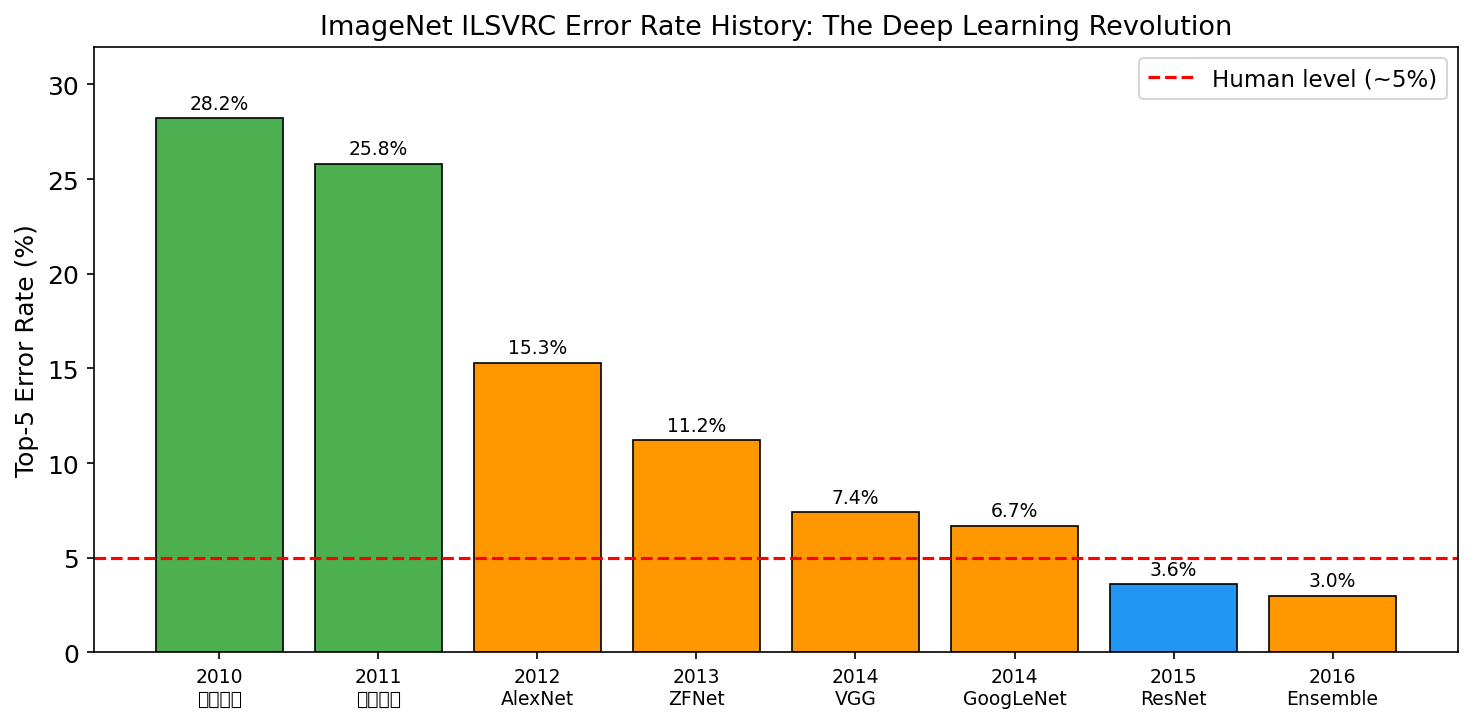

In [5]:
# Visualize ImageNet error rate history
import numpy as np
import matplotlib.pyplot as plt

# ImageNet ILSVRC top-5 error rates over years
years = [2010, 2011, 2012, 2013, 2014, 2014, 2015, 2016]
errors = [28.2, 25.8, 15.3, 11.2, 7.4, 6.7, 3.6, 3.0]
methods = ['手工特征', '手工特征', 'AlexNet', 'ZFNet', 'VGG', 'GoogLeNet', 'ResNet', 'Ensemble']

colors = ['#4CAF50' if e > 20 else '#2196F3' if 'Res' in m else '#FF9800' for e, m in zip(errors, methods)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(years)), errors, color=colors, edgecolor='black', linewidth=0.8)
ax.set_xticks(range(len(years)))
ax.set_xticklabels([f'{y}\n{m}' for y, m in zip(years, methods)], fontsize=9)
ax.set_ylabel('Top-5 Error Rate (%)', fontsize=12)
ax.set_title('ImageNet ILSVRC Error Rate History: The Deep Learning Revolution', fontsize=13)
ax.axhline(y=5.0, color='red', linestyle='--', label='Human level (~5%)')
ax.legend(fontsize=11)
ax.set_ylim(0, 32)
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{err}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('nb6_imagenet_history.png', dpi=150)
plt.show()
print("Figure saved: nb6_imagenet_history.png")


## 1.3 VGG: 小即是美

**VGG** (Oxford, 2014) 的核心洞察:

> **两个3x3卷积核的堆叠,其感受野等价于一个5x5卷积核,但参数更少且非线性更强。**

### 为什么小卷积核更好?

1. **更少的参数**: 两个3x3卷积核参数量 = 2 * 9 * C * C = 18C^2; 一个5x5卷积核参数量 = 25C^2
2. **更强的非线性**: 两层3x3比一层5x5多一次ReLU激活
3. **相同的感受野**: 两个3x3堆叠 = 5x5感受野

### 感受野计算
- 单个3x3卷积: 感受野 = 3
- 两个3x3卷积堆叠: 感受野 = 3 + (3-1)*1 = 5
- 三个3x3卷积堆叠: 感受野 = 3 + (3-1)*2 = 7

**VGG-16** 使用了13个卷积层 (全为3x3) 和3个全连接层,总参数约138M。


Figure saved: nb6_kernel_comparison.png

5x5 kernel: 0.1M params, 1 ReLU
2x 3x3 stack: 0.1M params, 2 ReLUs
Reduction: 28% fewer parameters


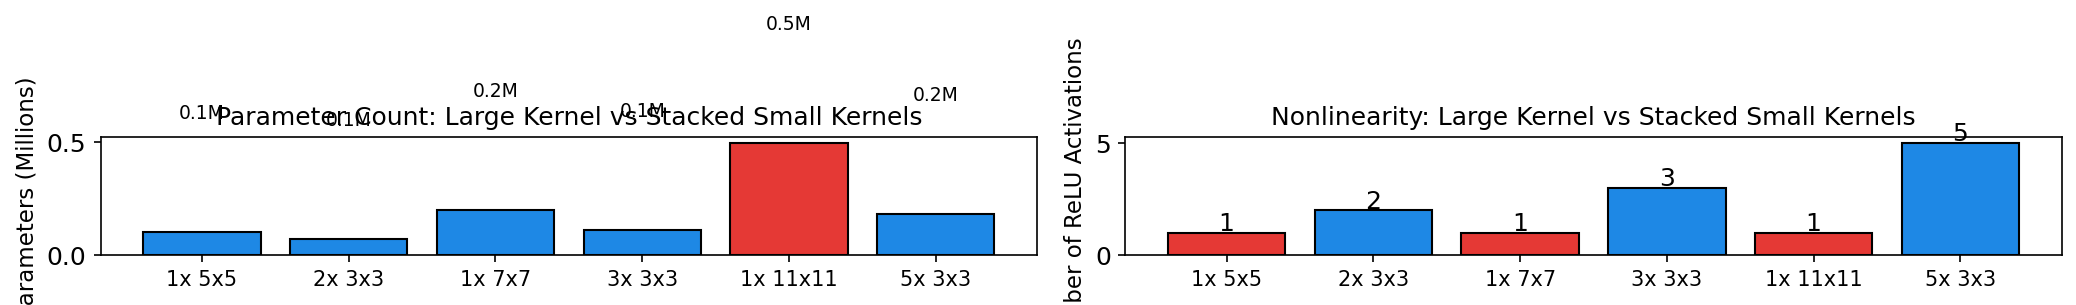

In [7]:
# Compare small vs large convolution kernels
import numpy as np
import matplotlib.pyplot as plt

# Parameter comparison: stacked 3x3 vs single large kernel
configs = ['1x 5x5', '2x 3x3', '1x 7x7', '3x 3x3', '1x 11x11', '5x 3x3']
receptive_fields = [5, 5, 7, 7, 11, 11]
# Assuming C_in = C_out = C = 64
C = 64
params_5x5 = 25 * C * C
params_2x_3x3 = 2 * 9 * C * C
params_7x7 = 49 * C * C
params_3x_3x3 = 3 * 9 * C * C
params_11x11 = 121 * C * C
params_5x_3x3 = 5 * 9 * C * C
params_list = [params_5x5, params_2x_3x3, params_7x7, params_3x_3x3, params_11x11, params_5x_3x3]
params_M = [p / 1e6 for p in params_list]
nonlinearities = [1, 2, 1, 3, 1, 5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parameter comparison
colors = ['#E53935' if 'large' in c or '11' in c else '#1E88E5' for c in configs]
axes[0].bar(range(len(configs)), params_M, color=colors, edgecolor='black')
axes[0].set_xticks(range(len(configs)))
axes[0].set_xticklabels(configs, fontsize=10)
axes[0].set_ylabel('Parameters (Millions)', fontsize=11)
axes[0].set_title('Parameter Count: Large Kernel vs Stacked Small Kernels', fontsize=12)
for i, v in enumerate(params_M):
    axes[0].text(i, v + 0.5, f'{v:.1f}M', ha='center', fontsize=9)

# Nonlinearity comparison
axes[1].bar(range(len(configs)), nonlinearities, color=['#E53935' if n == 1 else '#1E88E5' for n in nonlinearities], edgecolor='black')
axes[1].set_xticks(range(len(configs)))
axes[1].set_xticklabels(configs, fontsize=10)
axes[1].set_ylabel('Number of ReLU Activations', fontsize=11)
axes[1].set_title('Nonlinearity: Large Kernel vs Stacked Small Kernels', fontsize=12)
for i, v in enumerate(nonlinearities):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('nb6_kernel_comparison.png', dpi=150)
plt.show()
print("Figure saved: nb6_kernel_comparison.png")
print(f"\n5x5 kernel: {params_5x5/1e6:.1f}M params, 1 ReLU")
print(f"2x 3x3 stack: {params_2x_3x3/1e6:.1f}M params, 2 ReLUs")
print(f"Reduction: {(1 - params_2x_3x3/params_5x5)*100:.0f}% fewer parameters")


## 1.4 ResNet: 突破深度极限

### 问题: 网络越深,反而越难训练

2015年,何恺明团队发现一个反直觉的现象:
- 56层网络比20层网络在训练集上的错误率**更高**
- 这不是过拟合 (训练集错误率也高!)
- 根本原因是 **梯度消失/梯度退化**

### ResNet的解决方案: 残差连接 (Skip Connection)

核心思想极其简洁:

$$H(x) = F(x) + x$$

- $x$ 是输入 (恒等映射)
- $F(x)$ 是残差映射 (网络需要学习的部分)
- $H(x)$ 是期望的输出

**为什么有效?**
1. 如果最优映射是恒等映射, 只需让 $F(x) = 0$
2. 梯度可以直接通过 $x$ 的通路反向传播, 不经过 $F(x)$
3. 极深的网络 (152层!) 可以有效训练

### 残差块结构
```
Input --> Conv -> BN -> ReLU -> Conv -> BN --(+)--> ReLU --> Output
  \_______________________________________/
                    (skip connection)
```


Figure saved: nb6_gradient_flow.png


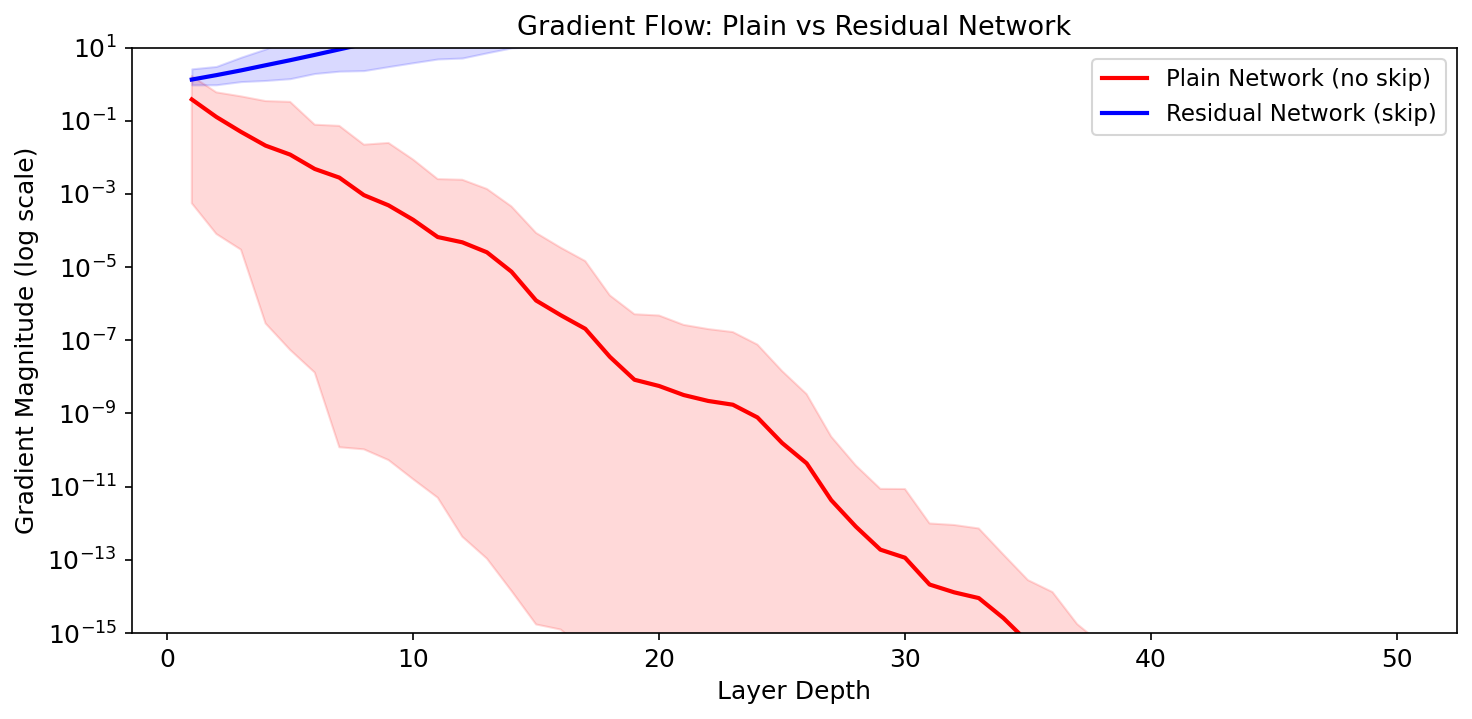

In [9]:
# Demonstrate gradient vanishing problem without residual connections
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_gradient_flow(depth, use_residual=False):
    """Simulate gradient magnitude through a deep network."""
    gradients = []
    grad = 1.0  # initial gradient
    for layer in range(depth):
        # Simulate weight multiplication effect on gradient
        # Without residual: gradient shrinks (vanishing) or grows (exploding)
        # With residual: gradient has a direct path, so it doesn't vanish
        if use_residual:
            # Residual: grad = grad * w + grad (identity path)
            w = np.random.randn() * 0.5  # smaller weights in residual branch
            grad = grad * abs(w) + grad * 0.95  # identity path preserves gradient
        else:
            # Plain: grad = grad * w
            w = np.random.randn() * 0.5
            grad = grad * abs(w)
        gradients.append(grad)
    return gradients

depths = list(range(1, 51))
trials = 100

# Average over multiple trials
plain_grads = np.zeros((trials, 50))
residual_grads = np.zeros((trials, 50))

for t in range(trials):
    np.random.seed(t)
    plain_grads[t] = simulate_gradient_flow(50, use_residual=False)
    np.random.seed(t)
    residual_grads[t] = simulate_gradient_flow(50, use_residual=True)

plain_mean = plain_grads.mean(axis=0)
residual_mean = residual_grads.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(range(1, 51), plain_mean, 'r-', linewidth=2, label='Plain Network (no skip)')
ax.semilogy(range(1, 51), residual_mean, 'b-', linewidth=2, label='Residual Network (skip)')
ax.fill_between(range(1, 51), plain_grads.min(axis=0), plain_grads.max(axis=0), alpha=0.15, color='red')
ax.fill_between(range(1, 51), residual_grads.min(axis=0), residual_grads.max(axis=0), alpha=0.15, color='blue')
ax.set_xlabel('Layer Depth', fontsize=12)
ax.set_ylabel('Gradient Magnitude (log scale)', fontsize=12)
ax.set_title('Gradient Flow: Plain vs Residual Network', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(1e-15, 10)
plt.tight_layout()
plt.savefig('nb6_gradient_flow.png', dpi=150)
plt.show()
print("Figure saved: nb6_gradient_flow.png")


## 1.5 BatchNorm: 训练加速器

### 问题: 内部协变量偏移 (Internal Covariate Shift)

在深层网络中,每一层的输入分布会随着前层参数的更新而变化。这导致:
- 训练不稳定,需要很小的学习率
- 收敛速度慢
- 对初始化敏感

### BatchNorm的解决方案

对每个mini-batch的每个特征进行归一化:

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

然后通过可学习参数进行缩放和平移:

$$y = \gamma \hat{x} + \beta$$

- $\mu_B$: batch均值
- $\sigma_B^2$: batch方差
- $\gamma, \beta$: 可学习参数 (恢复表达能力)
- $\epsilon$: 数值稳定常数

### 效果
- 训练速度提升约 **14倍**
- 允许使用更大的学习率
- 减少对初始化的敏感度
- 成为现代深度网络的标配


Figure saved: nb6_batchnorm_effect.png


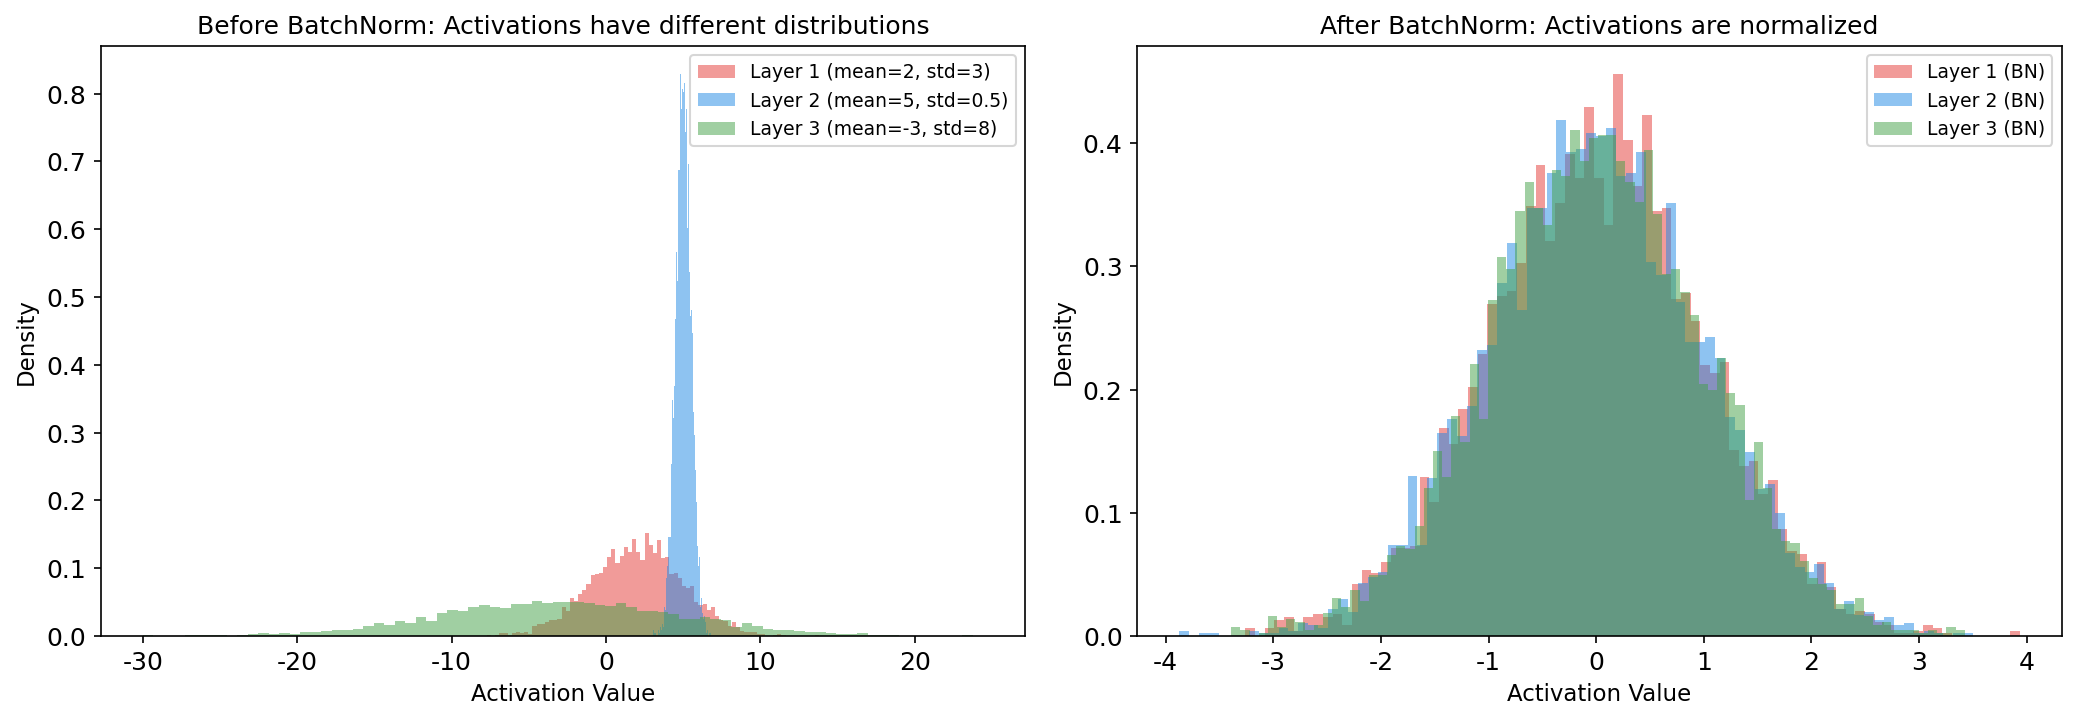

In [11]:
# Visualize BatchNorm effect on activation distributions
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate activations from a deep layer (before BN)
# These have varying means and stds due to internal covariate shift
n_samples = 5000
layer1_act = np.random.randn(n_samples) * 3 + 2      # mean=2, std=3
layer2_act = np.random.randn(n_samples) * 0.5 + 5    # mean=5, std=0.5
layer3_act = np.random.randn(n_samples) * 8 - 3      # mean=-3, std=8

# Apply BatchNorm
def batchnorm(x, gamma=1.0, beta=0.0, eps=1e-5):
    mean = x.mean()
    var = x.var()
    x_norm = (x - mean) / np.sqrt(var + eps)
    return gamma * x_norm + beta

layer1_bn = batchnorm(layer1_act)
layer2_bn = batchnorm(layer2_act)
layer3_bn = batchnorm(layer3_act)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before BN
for act, label, color in [(layer1_act, 'Layer 1 (mean=2, std=3)', '#E53935'),
                           (layer2_act, 'Layer 2 (mean=5, std=0.5)', '#1E88E5'),
                           (layer3_act, 'Layer 3 (mean=-3, std=8)', '#43A047')]:
    axes[0].hist(act, bins=80, alpha=0.5, label=label, color=color, density=True)
axes[0].set_title('Before BatchNorm: Activations have different distributions', fontsize=12)
axes[0].set_xlabel('Activation Value', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend(fontsize=9)

# After BN
for act, label, color in [(layer1_bn, 'Layer 1 (BN)', '#E53935'),
                           (layer2_bn, 'Layer 2 (BN)', '#1E88E5'),
                           (layer3_bn, 'Layer 3 (BN)', '#43A047')]:
    axes[1].hist(act, bins=80, alpha=0.5, label=label, color=color, density=True)
axes[1].set_title('After BatchNorm: Activations are normalized', fontsize=12)
axes[1].set_xlabel('Activation Value', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('nb6_batchnorm_effect.png', dpi=150)
plt.show()
print("Figure saved: nb6_batchnorm_effect.png")


## 1.6 Dropout: 集成的智慧

### 直觉

Dropout由Hinton等人提出 (2012), 核心思想:
- 训练时以概率 $p$ 随机将神经元置零
- 测试时不dropout, 但权重乘以 $(1-p)$ (或训练时做inverted dropout)

### 为什么Dropout有效?

1. **防止共适应 (Co-adaptation)**: 神经元不能依赖特定其他神经元,必须独立学习有用特征
2. **模型集成效果**: 每个mini-batch训练的是不同的子网络,相当于训练了指数级数量的网络
3. **近似贝叶斯推理**: Dropout可以被解释为变分推理的近似

### Inverted Dropout (标准实现)

训练时:
$$\text{mask} \sim \text{Bernoulli}(1-p)$$
$$\tilde{x} = x \odot \frac{\text{mask}}{1-p}$$

测试时: 直接使用 $x$ (无需缩放)

Inverted Dropout的优势: 测试时无需修改, 适合部署。


Figure saved: nb6_dropout_effect.png


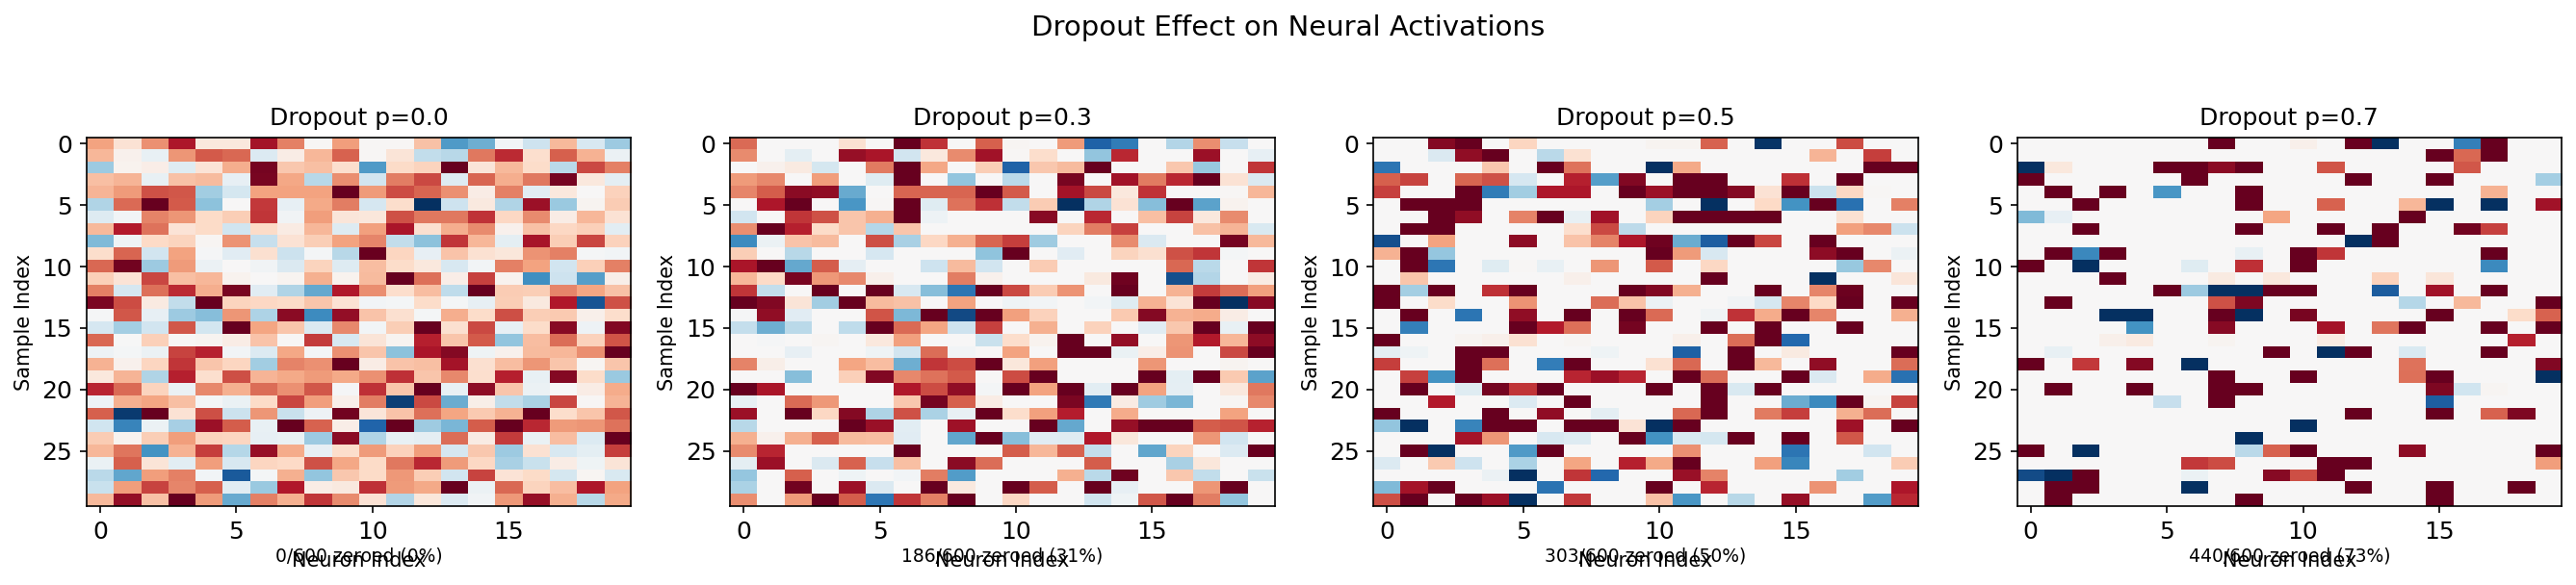

In [13]:
# Visualize Dropout effect during training
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate a layer with 50 neurons, 200 samples
n_neurons = 50
n_samples = 200
activations = np.random.randn(n_samples, n_neurons) * 2 + 1

# Apply dropout with different rates
dropout_rates = [0.0, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, p in enumerate(dropout_rates):
    if p == 0:
        dropped = activations.copy()
    else:
        # Inverted dropout
        mask = (np.random.rand(*activations.shape) > p) / (1 - p)
        dropped = activations * mask
    
    im = axes[idx].imshow(dropped[:30, :20], cmap='RdBu_r', aspect='auto', vmin=-5, vmax=5)
    axes[idx].set_title(f'Dropout p={p}', fontsize=12)
    axes[idx].set_xlabel('Neuron Index', fontsize=10)
    axes[idx].set_ylabel('Sample Index', fontsize=10)
    
    n_zeroed = np.sum(dropped[:30, :20] == 0)
    axes[idx].text(0.5, -0.15, f'{n_zeroed}/{30*20} zeroed ({n_zeroed/(30*20)*100:.0f}%)',
                   transform=axes[idx].transAxes, ha='center', fontsize=9)

plt.suptitle('Dropout Effect on Neural Activations', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb6_dropout_effect.png', dpi=150)
plt.show()
print("Figure saved: nb6_dropout_effect.png")


---
# Part 2: 手动计算

## 2.1 VGG感受野手动计算

**感受野 (Receptive Field)**: 输出特征图上一个像素对应输入图像上的区域大小。

### 计算公式

$$RF_{l} = RF_{l-1} + (k_l - 1) \times \prod_{i=1}^{l-1} s_i$$

其中:
- $RF_l$ 是第 $l$ 层的感受野
- $k_l$ 是第 $l$ 层卷积核大小
- $s_i$ 是第 $i$ 层的步长
- $RF_0 = 1$ (输入层)

### 手动计算VGG-16的感受野

| 层 | 操作 | 核大小 | 步长 | 累积步长 | 感受野 |
|----|------|--------|------|---------|--------|
| 0 | Input | - | - | 1 | 1 |
| 1 | Conv | 3 | 1 | 1 | 3 |
| 2 | Conv | 3 | 1 | 1 | 5 |
| 3 | Pool | 2 | 2 | 2 | 6 |
| 4 | Conv | 3 | 1 | 2 | 10 |
| 5 | Conv | 3 | 1 | 2 | 14 |
| 6 | Pool | 2 | 2 | 4 | 16 |
| ... | ... | ... | ... | ... | ... |
| 最终 | Pool | 2 | 2 | 16 | 196 |

VGG-16最终层感受野为 **196x196**, 基本覆盖了224x224的输入图像。


In [15]:
# VGG-16 receptive field calculation (step by step)
import numpy as np

# VGG-16 architecture definition
layers = [
    ('conv1_1', 3, 1), ('conv1_2', 3, 1), ('pool1', 2, 2),
    ('conv2_1', 3, 1), ('conv2_2', 3, 1), ('pool2', 2, 2),
    ('conv3_1', 3, 1), ('conv3_2', 3, 1), ('conv3_3', 3, 1), ('pool3', 2, 2),
    ('conv4_1', 3, 1), ('conv4_2', 3, 1), ('conv4_3', 3, 1), ('pool4', 2, 2),
    ('conv5_1', 3, 1), ('conv5_2', 3, 1), ('conv5_3', 3, 1), ('pool5', 2, 2),
]

rf = 1  # initial receptive field
cum_stride = 1  # cumulative stride
input_size = 224

print(f"{'Layer':<12} {'Kernel':<8} {'Stride':<8} {'CumStride':<12} {'ReceptiveField':<16} {'OutputSize':<12}")
print("-" * 70)

current_size = input_size
for name, k, s in layers:
    rf = rf + (k - 1) * cum_stride
    cum_stride = cum_stride * s
    current_size = current_size // s if name.startswith('pool') else current_size
    print(f"{name:<12} {k:<8} {s:<8} {cum_stride:<12} {rf:<16} {current_size:<12}")

print(f"\nFinal receptive field: {rf}x{rf}")
print(f"Input image size: {input_size}x{input_size}")
print(f"Final feature map size: {current_size}x{current_size}")
print(f"Coverage: {rf*rf / (input_size*input_size) * 100:.1f}% of input image")


Layer        Kernel   Stride   CumStride    ReceptiveField   OutputSize  
----------------------------------------------------------------------
conv1_1      3        1        1            3                224         
conv1_2      3        1        1            5                224         
pool1        2        2        2            6                112         
conv2_1      3        1        2            10               112         
conv2_2      3        1        2            14               112         
pool2        2        2        4            16               56          
conv3_1      3        1        4            24               56          
conv3_2      3        1        4            32               56          
conv3_3      3        1        4            40               56          
pool3        2        2        8            44               28          
conv4_1      3        1        8            60               28          
conv4_2      3        1        8         

## 2.2 ResNet残差块手动计算

### 残差块的前向传播

给定输入 $x$, 残差块的计算过程:

1. **第一个卷积层**: $y_1 = W_1 x + b_1$
2. **BatchNorm**: $y_2 = \gamma_1 \frac{y_1 - \mu_1}{\sqrt{\sigma_1^2 + \epsilon}} + \beta_1$
3. **ReLU**: $y_3 = \max(0, y_2)$
4. **第二个卷积层**: $y_4 = W_2 y_3 + b_2$
5. **BatchNorm**: $y_5 = \gamma_2 \frac{y_4 - \mu_2}{\sqrt{\sigma_2^2 + \epsilon}} + \beta_2$
6. **残差相加**: $y_6 = y_5 + x$
7. **ReLU**: $y_{out} = \max(0, y_6)$

### 数值示例

假设输入 $x = [2.0, -1.0, 0.5]$, 手动计算:

**Step 1**: $y_1 = W_1 x$ (简化为逐元素乘法 $W_1 = [0.5, 0.5, 0.5]$)
$y_1 = [1.0, -0.5, 0.25]$

**Step 2**: BatchNorm (假设 $\mu=0, \sigma=0.5, \gamma=1, \beta=0$)
$y_2 = y_1 / 0.5 = [2.0, -1.0, 0.5]$

**Step 3**: ReLU
$y_3 = [2.0, 0, 0.5]$

**Step 4**: $y_4 = W_2 y_3$ (假设 $W_2 = [0.5, 0.5, 0.5]$)
$y_4 = [1.0, 0, 0.25]$

**Step 5**: BatchNorm ($\mu=0.5, \sigma=0.5, \gamma=1, \beta=0$)
$y_5 = (y_4 - 0.5) / 0.5 = [1.0, -1.0, -0.5]$

**Step 6**: 残差相加 $y_6 = y_5 + x = [1.0+2.0, -1.0+(-1.0), -0.5+0.5] = [3.0, -2.0, 0.0]$

**Step 7**: ReLU $y_{out} = [3.0, 0, 0.0]$


In [17]:
# Manual calculation of residual block forward pass
import numpy as np

def manual_residual_block(x, W1, W2, gamma1, beta1, gamma2, beta2, eps=1e-5):
    """Manual implementation of a residual block for educational purposes."""
    print(f"Input x: {x}")
    
    # Step 1: First conv (simplified as element-wise multiply)
    y1 = x * W1
    print(f"Step 1 - Conv1 (y1 = W1 * x): {y1}")
    
    # Step 2: BatchNorm 1
    mu1 = y1.mean()
    var1 = y1.var()
    y2 = gamma1 * (y1 - mu1) / np.sqrt(var1 + eps) + beta1
    print(f"Step 2 - BN1 (mu={mu1:.4f}, var={var1:.4f}): {y2}")
    
    # Step 3: ReLU
    y3 = np.maximum(0, y2)
    print(f"Step 3 - ReLU: {y3}")
    
    # Step 4: Second conv
    y4 = y3 * W2
    print(f"Step 4 - Conv2 (y4 = W2 * y3): {y4}")
    
    # Step 5: BatchNorm 2
    mu2 = y4.mean()
    var2 = y4.var()
    y5 = gamma2 * (y4 - mu2) / np.sqrt(var2 + eps) + beta2
    print(f"Step 5 - BN2 (mu={mu2:.4f}, var={var2:.4f}): {y5}")
    
    # Step 6: Skip connection
    y6 = y5 + x
    print(f"Step 6 - Skip (y6 = y5 + x): {y6}")
    
    # Step 7: Final ReLU
    y_out = np.maximum(0, y6)
    print(f"Step 7 - ReLU: {y_out}")
    
    return y_out

# Run manual calculation
x = np.array([2.0, -1.0, 0.5])
W1 = np.array([0.5, 0.5, 0.5])
W2 = np.array([0.5, 0.5, 0.5])
print("=== Residual Block Manual Calculation ===")
output = manual_residual_block(x, W1, W2, gamma1=1.0, beta1=0.0, gamma2=1.0, beta2=0.0)
print(f"\nFinal output: {output}")

# Compare: without residual connection
print("\n=== Without Residual Connection (same block, no skip) ===")
y1 = x * W1
mu1 = y1.mean(); var1 = y1.var()
y2 = (y1 - mu1) / np.sqrt(var1 + 1e-5)
y3 = np.maximum(0, y2)
y4 = y3 * W2
mu2 = y4.mean(); var2 = y4.var()
y5 = (y4 - mu2) / np.sqrt(var2 + 1e-5)
y_out_no_res = np.maximum(0, y5)
print(f"Output without residual: {y_out_no_res}")
print(f"Output with residual:    {output}")
print(f"Difference: residual adds {output - y_out_no_res}")


=== Residual Block Manual Calculation ===
Input x: [ 2.  -1.   0.5]
Step 1 - Conv1 (y1 = W1 * x): [ 1.   -0.5   0.25]
Step 2 - BN1 (mu=0.2500, var=0.3750): [ 1.22472854 -1.22472854  0.        ]
Step 3 - ReLU: [1.22472854 0.         0.        ]
Step 4 - Conv2 (y4 = W2 * y3): [0.61236427 0.         0.        ]
Step 5 - BN2 (mu=0.2041, var=0.0833): [ 1.41412871 -0.70706436 -0.70706436]
Step 6 - Skip (y6 = y5 + x): [ 3.41412871 -1.70706436 -0.20706436]
Step 7 - ReLU: [3.41412871 0.         0.        ]

Final output: [3.41412871 0.         0.        ]

=== Without Residual Connection (same block, no skip) ===
Output without residual: [1.41412871 0.         0.        ]
Output with residual:    [3.41412871 0.         0.        ]
Difference: residual adds [2. 0. 0.]


## 2.3 BatchNorm手动计算

### 给定一个mini-batch

假设有4个样本,每个样本3个特征:

$$X = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \\ 10 & 11 & 12 \end{bmatrix}$$

### Step 1: 计算每个特征的均值
$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i = [5.5, 6.5, 7.5]$$

### Step 2: 计算每个特征的方差
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2 = [11.25, 11.25, 11.25]$$

### Step 3: 归一化
$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

以 $x_1 = [1, 2, 3]$ 为例:
$$\hat{x}_1 = \frac{[1, 2, 3] - [5.5, 6.5, 7.5]}{\sqrt{11.25 + 10^{-5}}} = \frac{[-4.5, -4.5, -4.5]}{3.354} \approx [-1.34, -1.34, -1.34]$$

### Step 4: 缩放和平移
假设 $\gamma = [2, 2, 2]$, $\beta = [1, 1, 1]$:
$$y_1 = \gamma \odot \hat{x}_1 + \beta = [2 \times (-1.34) + 1, ...] = [-1.68, -1.68, -1.68]$$


In [19]:
# BatchNorm manual calculation (step by step)
import numpy as np

# Mini-batch: 4 samples, 3 features
X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]], dtype=np.float64)

print("=== BatchNorm Manual Calculation ===")
print(f"Input X (4x3):\n{X}\n")

# Step 1: Compute mean per feature
mu = X.mean(axis=0)
print(f"Step 1 - Mean mu = {mu}")

# Step 2: Compute variance per feature
var = X.var(axis=0)  # Uses 1/N (population variance)
print(f"Step 2 - Variance var = {var}")

# Step 3: Normalize
eps = 1e-5
std = np.sqrt(var + eps)
x_hat = (X - mu) / std
print(f"Step 3 - Normalized x_hat =\n{x_hat}\n")

# Step 4: Scale and shift
gamma = np.array([2.0, 2.0, 2.0])
beta = np.array([1.0, 1.0, 1.0])
y = gamma * x_hat + beta
print(f"Step 4 - gamma = {gamma}, beta = {beta}")
print(f"Output y = gamma * x_hat + beta =\n{y}\n")

# Verify: mean should be close to beta, std close to gamma
print("=== Verification ===")
print(f"Output mean per feature: {y.mean(axis=0)} (should be close to beta={beta})")
print(f"Output std per feature:  {y.std(axis=0)} (should be close to gamma={gamma})")

# Compare with a simple implementation
print("\n=== Comparison: Without BN vs With BN ===")
print(f"Without BN - mean: {X.mean(axis=0)}, std: {X.std(axis=0)}")
print(f"With BN - mean: {y.mean(axis=0)}, std: {y.std(axis=0)}")


=== BatchNorm Manual Calculation ===
Input X (4x3):
[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]

Step 1 - Mean mu = [5.5 6.5 7.5]
Step 2 - Variance var = [11.25 11.25 11.25]
Step 3 - Normalized x_hat =
[[-1.34164019 -1.34164019 -1.34164019]
 [-0.4472134  -0.4472134  -0.4472134 ]
 [ 0.4472134   0.4472134   0.4472134 ]
 [ 1.34164019  1.34164019  1.34164019]]

Step 4 - gamma = [2. 2. 2.], beta = [1. 1. 1.]
Output y = gamma * x_hat + beta =
[[-1.68328038 -1.68328038 -1.68328038]
 [ 0.10557321  0.10557321  0.10557321]
 [ 1.89442679  1.89442679  1.89442679]
 [ 3.68328038  3.68328038  3.68328038]]

=== Verification ===
Output mean per feature: [1. 1. 1.] (should be close to beta=[1. 1. 1.])
Output std per feature:  [1.99999911 1.99999911 1.99999911] (should be close to gamma=[2. 2. 2.])

=== Comparison: Without BN vs With BN ===
Without BN - mean: [5.5 6.5 7.5], std: [3.35410197 3.35410197 3.35410197]
With BN - mean: [1. 1. 1.], std: [1.99999911 1.99999911 1.99999911]


## 2.4 Dropout手动计算

### Inverted Dropout示例

给定一个4神经元的层, 激活值为:
$$x = [0.5, -0.3, 0.8, 0.1]$$

Dropout率 $p = 0.5$:

### Step 1: 生成掩码
$$\text{mask} = \text{Bernoulli}(1-p, \text{shape}=4) = [1, 0, 1, 0]$$
(随机结果, 第2和第4个被丢弃)

### Step 2: 缩放掩码 (Inverted Dropout)
$$\text{mask}_{scaled} = \frac{\text{mask}}{1-p} = \frac{[1, 0, 1, 0]}{0.5} = [2, 0, 2, 0]$$

### Step 3: 应用Dropout
$$\tilde{x} = x \odot \text{mask}_{scaled} = [0.5 \times 2, -0.3 \times 0, 0.8 \times 2, 0.1 \times 0] = [1.0, 0, 1.6, 0]$$

### 为什么需要缩放?
- 训练时丢弃了50%的神经元, 剩余神经元的期望值不变
- 缩放确保: $E[\tilde{x}] = E[x]$ (期望保持不变)
- 测试时无需任何修改, 直接使用原始权重

### 数学验证
$$E[\tilde{x}_i] = (1-p) \times \frac{x_i}{1-p} + p \times 0 = x_i$$


In [21]:
# Dropout manual calculation (step by step)
import numpy as np

np.random.seed(42)

# Input activations
x = np.array([0.5, -0.3, 0.8, 0.1])
p = 0.5  # dropout rate

print("=== Dropout Manual Calculation ===")
print(f"Input x: {x}")
print(f"Dropout rate p: {p}")
print()

# Step 1: Generate mask
mask = (np.random.rand(len(x)) > p).astype(float)
print(f"Step 1 - Raw mask (Bernoulli): {mask}")
print(f"  Neurons kept: {int(mask.sum())}/{len(x)}")

# Step 2: Scale mask (inverted dropout)
mask_scaled = mask / (1 - p)
print(f"Step 2 - Scaled mask (mask / (1-p)): {mask_scaled}")

# Step 3: Apply dropout
x_dropped = x * mask_scaled
print(f"Step 3 - Output (x * scaled_mask): {x_dropped}")

print(f"
=== Expected value analysis ===")
# Run many times to verify E[x_dropped] = E[x]
n_trials = 100000
results = np.zeros((n_trials, len(x)))
for t in range(n_trials):
    m = (np.random.rand(len(x)) > p).astype(float) / (1 - p)
    results[t] = x * m

print(f"Original x:        {x}")
print(f"Empirical E[x_drop]: {results.mean(axis=0)}")
print(f"Theoretical E[x_drop]: {x} (should match original)")
print(f"Empirical std:       {results.std(axis=0)}")

# Verify: test time (no dropout)
print(f"
Test time (no dropout): {x}")
print("Inverted dropout: test time requires NO scaling!")


SyntaxError: unterminated string literal (detected at line 28) (<cell_20>, line 28)

---
# Part 3: 代码实现

## 3.1 基础层实现

在实现完整网络之前,我们先实现所有基础组件:
- **conv2d**: 2D卷积 (简化版,用于教学)
- **maxpool2d**: 最大池化
- **relu**: ReLU激活函数
- **linear**: 全连接层
- **softmax + cross_entropy**: 分类输出

所有实现仅使用NumPy,不依赖PyTorch或TensorFlow。


In [23]:
# Base layer implementations (numpy only)
import numpy as np

def conv2d(x, kernel, stride=1, padding=0):
    """2D convolution (simplified, educational).
    x: (H, W, C_in), kernel: (kH, kW, C_in, C_out)
    Returns: (out_H, out_W, C_out)
    """
    if padding > 0:
        x = np.pad(x, ((padding, padding), (padding, padding), (0, 0)))
    H, W, C = x.shape
    kH, kW, C_in, C_out = kernel.shape
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1
    out = np.zeros((out_H, out_W, C_out))
    for i in range(out_H):
        for j in range(out_W):
            region = x[i*stride:i*stride+kH, j*stride:j*stride+kW, :]
            out[i, j] = np.tensordot(region, kernel, axes=([0,1,2],[0,1,2]))
    return out

def maxpool2d(x, size=2, stride=2):
    """Max pooling.
    x: (H, W, C), Returns: (out_H, out_W, C)
    """
    H, W, C = x.shape
    out_H = (H - size) // stride + 1
    out_W = (W - size) // stride + 1
    out = np.zeros((out_H, out_W, C))
    for i in range(out_H):
        for j in range(out_W):
            region = x[i*stride:i*stride+size, j*stride:j*stride+size, :]
            out[i, j] = region.max(axis=(0,1))
    return out

def relu(x):
    """ReLU activation."""
    return np.maximum(0, x)

def linear(x, w, b):
    """Fully connected layer.
    x: (N, D_in), w: (D_in, D_out), b: (D_out,)
    """
    return x @ w + b

def softmax(x):
    """Softmax along last axis."""
    x = x - x.max(axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

def cross_entropy(probs, labels):
    """Cross-entropy loss.
    probs: (N, C), labels: (N,) integer
    """
    eps = 1e-7
    N = len(labels)
    return -np.log(probs[np.arange(N), labels] + eps).mean()

# Quick test
np.random.seed(42)
x_test = np.random.randn(8, 8, 3)  # 8x8 image with 3 channels
kernel_test = np.random.randn(3, 3, 3, 4) * 0.1  # 3x3 kernel, 3->4 channels
out = conv2d(x_test, kernel_test, stride=1, padding=1)
print(f"Conv2d: input {x_test.shape} -> output {out.shape}")

pooled = maxpool2d(out, size=2, stride=2)
print(f"MaxPool: input {out.shape} -> output {pooled.shape}")

fc_in = pooled.reshape(-1)
fc_w = np.random.randn(len(fc_in), 10) * 0.01
fc_b = np.zeros(10)
fc_out = linear(fc_in, fc_w, fc_b)
print(f"Linear: input {fc_in.shape} -> output {fc_out.shape}")

probs = softmax(fc_out)
print(f"Softmax: {probs}")
print(f"Sum of probs: {probs.sum():.4f} (should be 1.0)")


Conv2d: input (8, 8, 3) -> output (8, 8, 4)
MaxPool: input (8, 8, 4) -> output (4, 4, 4)
Linear: input (64,) -> output (10,)
Softmax: [0.1001237  0.09977814 0.09752628 0.10461097 0.10122784 0.09918949
 0.09720358 0.10271115 0.09814825 0.09948061]
Sum of probs: 1.0000 (should be 1.0)


## 3.2 AlexNet简化实现

AlexNet结构 (简化版,使用单个GPU):

| 层 | 类型 | 参数 | 输出尺寸 |
|----|------|------|---------|
| 0 | Input | - | 224x224x3 |
| 1 | Conv | 11x11, s=4, 96ch | 55x55x96 |
| 2 | MaxPool | 3x3, s=2 | 27x27x96 |
| 3 | Conv | 5x5, 256ch | 27x27x256 |
| 4 | MaxPool | 3x3, s=2 | 13x13x256 |
| 5 | Conv | 3x3, 384ch | 13x13x384 |
| 6 | Conv | 3x3, 384ch | 13x13x384 |
| 7 | Conv | 3x3, 256ch | 13x13x256 |
| 8 | MaxPool | 3x3, s=2 | 6x6x256 |
| 9 | FC | 4096 | 4096 |
| 10 | FC | 4096 | 4096 |
| 11 | FC | 1000 (classes) | 1000 |

总参数量约 60M (原始AlexNet, 单GPU)


In [25]:
# AlexNet simplified implementation (using small input for demo)
import numpy as np

def alexnet_forward(x, params):
    """Simplified AlexNet forward pass.
    Uses smaller input for demonstration (32x32 instead of 224x224).
    """
    # Conv1: 11x11, stride=4, 96 channels (scaled down to 5x5, s=2, 16ch)
    x = conv2d(x, params['conv1_w'], stride=2, padding=2)
    x = relu(x)
    x = maxpool2d(x, size=3, stride=2)
    
    # Conv2: 5x5, 256 channels (scaled down to 3x3, 32ch)
    x = conv2d(x, params['conv2_w'], stride=1, padding=1)
    x = relu(x)
    x = maxpool2d(x, size=3, stride=2)
    
    # Conv3: 3x3, 384 channels (scaled down to 3x3, 48ch)
    x = conv2d(x, params['conv3_w'], stride=1, padding=1)
    x = relu(x)
    
    # Conv4: 3x3, 384 channels (scaled down to 3x3, 32ch)
    x = conv2d(x, params['conv4_w'], stride=1, padding=1)
    x = relu(x)
    
    # Conv5: 3x3, 256 channels (scaled down to 3x3, 32ch)
    x = conv2d(x, params['conv5_w'], stride=1, padding=1)
    x = relu(x)
    x = maxpool2d(x, size=3, stride=2)
    
    # Flatten
    x_flat = x.reshape(-1)
    
    # FC1
    x_flat = relu(linear(x_flat, params['fc1_w'], params['fc1_b']))
    # FC2
    x_flat = relu(linear(x_flat, params['fc2_w'], params['fc2_b']))
    # FC3 (output)
    x_flat = linear(x_flat, params['fc3_w'], params['fc3_b'])
    
    return x_flat

# Create simplified AlexNet parameters
np.random.seed(42)
input_size = 32  # 32x32 input (CIFAR-10 style)
params = {
    'conv1_w': np.random.randn(5, 5, 3, 16) * 0.01,
    'conv2_w': np.random.randn(3, 3, 16, 32) * 0.01,
    'conv3_w': np.random.randn(3, 3, 32, 48) * 0.01,
    'conv4_w': np.random.randn(3, 3, 48, 32) * 0.01,
    'conv5_w': np.random.randn(3, 3, 32, 32) * 0.01,
}

# Compute FC input size
dummy = np.zeros((input_size, input_size, 3))
# Trace shapes
s = input_size
# conv1: (32-5+2*2)/2+1 = 16, pool: (16-3)/2+1 = 7
# conv2: 7, pool: (7-3)/2+1 = 3
# conv3-5: 3, pool: (3-3)/2+1 = 1
fc_input_size = 1 * 1 * 32  # = 32
params['fc1_w'] = np.random.randn(fc_input_size, 64) * 0.01
params['fc1_b'] = np.zeros(64)
params['fc2_w'] = np.random.randn(64, 32) * 0.01
params['fc2_b'] = np.zeros(32)
params['fc3_w'] = np.random.randn(32, 10) * 0.01
params['fc3_b'] = np.zeros(10)

# Forward pass
x_input = np.random.randn(input_size, input_size, 3) * 0.5 + 0.5
output = alexnet_forward(x_input, params)
probs = softmax(output)

total_params = sum(p.size for p in params.values())
print(f"AlexNet (simplified) total parameters: {total_params:,}")
print(f"Input shape: {x_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (logits): {output}")
print(f"Softmax probs: {probs}")
print(f"Predicted class: {np.argmax(probs)}")


AlexNet (simplified) total parameters: 47,194
Input shape: (32, 32, 3)
Output shape: (10,)
Output (logits): [-6.48974461e-09 -7.20197105e-10  1.87214586e-09 -2.63032853e-09
 -2.43458797e-09 -6.81177799e-11 -2.67842503e-09 -1.33002715e-09
  2.78199803e-09 -1.04791364e-09]
Softmax probs: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Predicted class: 8


## 3.3 VGG-16简化实现

VGG-16的结构非常规整: 全部使用3x3卷积, 每个block后接2x2最大池化。

### VGG-16卷积层配置
```
Block 1: [Conv3x3-64, Conv3x3-64] -> Pool
Block 2: [Conv3x3-128, Conv3x3-128] -> Pool
Block 3: [Conv3x3-256, Conv3x3-256, Conv3x3-256] -> Pool
Block 4: [Conv3x3-512, Conv3x3-512, Conv3x3-512] -> Pool
Block 5: [Conv3x3-512, Conv3x3-512, Conv3x3-512] -> Pool
```

### 关键设计原则
1. 所有卷积核都是 **3x3, stride=1, padding=1** (保持空间尺寸)
2. 所有池化都是 **2x2, stride=2** (空间尺寸减半)
3. 每经过一次池化, 通道数翻倍


In [27]:
# VGG-16 simplified implementation
import numpy as np

def vgg_block(x, conv_params_list):
    """VGG conv block: multiple 3x3 convs + ReLU + maxpool."""
    for w in conv_params_list:
        x = conv2d(x, w, stride=1, padding=1)
        x = relu(x)
    x = maxpool2d(x, size=2, stride=2)
    return x

def vgg16_forward(x, params):
    """Simplified VGG-16 forward pass."""
    # Block 1: 2x Conv64
    x = vgg_block(x, [params['c1_1'], params['c1_2']])
    # Block 2: 2x Conv128
    x = vgg_block(x, [params['c2_1'], params['c2_2']])
    # Block 3: 3x Conv256
    x = vgg_block(x, [params['c3_1'], params['c3_2'], params['c3_3']])
    # Block 4: 3x Conv512 (scaled to 64)
    x = vgg_block(x, [params['c4_1'], params['c4_2'], params['c4_3']])
    # Block 5: 3x Conv512 (scaled to 64)
    x = vgg_block(x, [params['c5_1'], params['c5_2'], params['c5_3']])
    
    # FC layers
    x_flat = x.reshape(-1)
    x_flat = relu(linear(x_flat, params['fc1_w'], params['fc1_b']))
    x_flat = relu(linear(x_flat, params['fc2_w'], params['fc2_b']))
    x_flat = linear(x_flat, params['fc3_w'], params['fc3_b'])
    return x_flat

# Build simplified VGG (small channels for demo)
np.random.seed(42)
input_size = 64  # 64x64 input
c1, c2, c3, c4, c5 = 8, 16, 32, 48, 48  # scaled-down channels

params = {
    'c1_1': np.random.randn(3,3,3,c1)*0.01, 'c1_2': np.random.randn(3,3,c1,c1)*0.01,
    'c2_1': np.random.randn(3,3,c1,c2)*0.01, 'c2_2': np.random.randn(3,3,c2,c2)*0.01,
    'c3_1': np.random.randn(3,3,c2,c3)*0.01, 'c3_2': np.random.randn(3,3,c3,c3)*0.01, 'c3_3': np.random.randn(3,3,c3,c3)*0.01,
    'c4_1': np.random.randn(3,3,c3,c4)*0.01, 'c4_2': np.random.randn(3,3,c4,c4)*0.01, 'c4_3': np.random.randn(3,3,c4,c4)*0.01,
    'c5_1': np.random.randn(3,3,c4,c5)*0.01, 'c5_2': np.random.randn(3,3,c5,c5)*0.01, 'c5_3': np.random.randn(3,3,c5,c5)*0.01,
}
# 5 poolings: 64 -> 32 -> 16 -> 8 -> 4 -> 2
fc_in = 2*2*c5
params['fc1_w'] = np.random.randn(fc_in, 64)*0.01; params['fc1_b'] = np.zeros(64)
params['fc2_w'] = np.random.randn(64, 32)*0.01; params['fc2_b'] = np.zeros(32)
params['fc3_w'] = np.random.randn(32, 10)*0.01; params['fc3_b'] = np.zeros(10)

x_input = np.random.randn(input_size, input_size, 3) * 0.5 + 0.5
output = vgg16_forward(x_input, params)
total_params = sum(p.size for p in params.values())
print(f"VGG-16 (simplified) total parameters: {total_params:,}")
print(f"Input: {x_input.shape}, Output: {output.shape}")
print(f"Predicted class: {np.argmax(softmax(output))}")


VGG-16 (simplified) total parameters: 159,554
Input: (64, 64, 3), Output: (10,)
Predicted class: 0


## 3.4 ResNet残差块实现

### 标准残差块 (BasicBlock)

结构:
```
Input -> Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN --(+)--> ReLU -> Output
  \__________________________________________________/
                    (identity skip)
```

注意:
1. 第一个卷积后接BN和ReLU
2. 第二个卷积后只接BN (不接ReLU)
3. 残差相加后再接ReLU
4. 如果输入输出通道数不同, 需要用1x1卷积调整 (projection shortcut)


In [29]:
# ResNet residual block implementation
import numpy as np

def batchnorm_layer(x, gamma, beta, eps=1e-5):
    """BatchNorm forward pass.
    x: (H, W, C) or (N, D), gamma/beta: (C,) or (D,)
    """
    if x.ndim == 3:
        # For conv: normalize per channel
        mean = x.mean(axis=(0,1), keepdims=True)
        var = x.var(axis=(0,1), keepdims=True)
    else:
        # For FC: normalize per feature
        mean = x.mean(axis=0, keepdims=True)
        var = x.var(axis=0, keepdims=True)
    x_norm = (x - mean) / np.sqrt(var + eps)
    return gamma * x_norm + beta

def residual_block(x, params, prefix, stride=1):
    """ResNet basic residual block.
    Uses 3x3 conv with padding=1 (preserves spatial size when stride=1).
    """
    identity = x
    
    # First conv: 3x3, stride, BN, ReLU
    out = conv2d(x, params[f'{prefix}_w1'], stride=stride, padding=1)
    out = batchnorm_layer(out, params[f'{prefix}_g1'], params[f'{prefix}_b1'])
    out = relu(out)
    
    # Second conv: 3x3, stride=1, BN (no ReLU!)
    out = conv2d(out, params[f'{prefix}_w2'], stride=1, padding=1)
    out = batchnorm_layer(out, params[f'{prefix}_g2'], params[f'{prefix}_b2'])
    
    # Skip connection (identity or projection)
    if stride != 1 or x.shape[-1] != out.shape[-1]:
        # Projection shortcut: 1x1 conv
        identity = conv2d(identity, params[f'{prefix}_proj_w'], stride=stride, padding=0)
        identity = batchnorm_layer(identity, params[f'{prefix}_proj_g'], params[f'{prefix}_proj_b'])
    
    # Add and ReLU
    out = relu(out + identity)
    return out

# Test residual block
np.random.seed(42)
C_in, C_out = 8, 8
x_test = np.random.randn(8, 8, C_in) * 0.5

params = {
    'rb_w1': np.random.randn(3,3,C_in,C_out)*0.01,
    'rb_g1': np.ones(C_out), 'rb_b1': np.zeros(C_out),
    'rb_w2': np.random.randn(3,3,C_out,C_out)*0.01,
    'rb_g2': np.ones(C_out), 'rb_b2': np.zeros(C_out),
}

out = residual_block(x_test, params, 'rb', stride=1)
print(f"Residual block: input {x_test.shape} -> output {out.shape}")
print(f"Output mean: {out.mean():.4f}, std: {out.std():.4f}")
print(f"All values non-negative: {(out >= 0).all()}")  # Should be True (after ReLU)


Residual block: input (8, 8, 8) -> output (8, 8, 8)
Output mean: 0.4391, std: 0.6331
All values non-negative: True


## 3.5 BatchNorm层完整实现

完整的BatchNorm需要处理两种模式:
1. **训练模式**: 使用当前batch的统计量, 并更新运行均值/方差
2. **测试模式**: 使用累积的运行均值/方差

### 运行统计量更新
$$\mu_{running} = \alpha \cdot \mu_{running} + (1-\alpha) \cdot \mu_{batch}$$
$$\sigma^2_{running} = \alpha \cdot \sigma^2_{running} + (1-\alpha) \cdot \sigma^2_{batch}$$

其中 $\alpha$ 是动量系数 (通常0.9或0.1)。


In [31]:
# Complete BatchNorm layer with training/test modes
import numpy as np

class BatchNorm:
    """Complete BatchNorm layer with running statistics."""
    
    def __init__(self, num_features, momentum=0.1, eps=1e-5):
        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)
        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)
        self.momentum = momentum
        self.eps = eps
        self.training = True
        # Cache for backward pass
        self.cache = {}
    
    def forward(self, x):
        """Forward pass.
        x: (N, D) for FC or (H, W, C) for conv (reshaped).
        """
        if x.ndim == 3:
            # Conv: transpose to (H*W, C)
            H, W, C = x.shape
            x_flat = x.reshape(-1, C)
        else:
            x_flat = x
        
        if self.training:
            # Training: use batch statistics
            mean = x_flat.mean(axis=0)
            var = x_flat.var(axis=0)
            x_norm = (x_flat - mean) / np.sqrt(var + self.eps)
            
            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var
            
            # Cache for backward
            self.cache = {'x_norm': x_norm, 'mean': mean, 'var': var, 'x_flat': x_flat}
        else:
            # Test: use running statistics
            x_norm = (x_flat - self.running_mean) / np.sqrt(self.running_var + self.eps)
        
        out = self.gamma * x_norm + self.beta
        
        if x.ndim == 3:
            out = out.reshape(H, W, C)
        
        return out
    
    def backward(self, dout):
        """Backward pass (simplified)."""
        N = dout.shape[0]
        x_norm = self.cache['x_norm']
        var = self.cache['var']
        
        # Gradient w.r.t. gamma and beta
        dgamma = (dout * x_norm).sum(axis=0)
        dbeta = dout.sum(axis=0)
        
        # Gradient w.r.t. input
        dx_norm = dout * self.gamma
        dvar = (dx_norm * (self.cache['x_flat'] - self.cache['mean']) * -0.5 * 
                (var + self.eps)**(-1.5)).sum(axis=0)
        dmean = (dx_norm * -1 / np.sqrt(var + self.eps)).sum(axis=0) + dvar * -2 * (self.cache['x_flat'] - self.cache['mean']).mean(axis=0)
        dx = dx_norm / np.sqrt(var + self.eps) + dvar * 2 * (self.cache['x_flat'] - self.cache['mean']) / N + dmean / N
        
        return dx, dgamma, dbeta

# Test BatchNorm
np.random.seed(42)
bn = BatchNorm(num_features=4)

# Training mode
x_train = np.random.randn(16, 4) * 3 + 2
print("=== Training Mode ===")
print(f"Input mean: {x_train.mean(axis=0)}")
print(f"Input std:  {x_train.std(axis=0)}")
out = bn.forward(x_train)
print(f"Output mean: {out.mean(axis=0)}")  # Should be ~0 (before gamma/beta)
print(f"Output std:  {out.std(axis=0)}")   # Should be ~1

# After multiple batches, running stats stabilize
for _ in range(100):
    x = np.random.randn(16, 4) * 3 + 2
    bn.forward(x)

print(f"
Running mean after 100 batches: {bn.running_mean}")
print(f"Running var after 100 batches:  {bn.running_var}")

# Test mode
bn.training = False
x_test = np.random.randn(8, 4) * 3 + 2
out_test = bn.forward(x_test)
print(f"
=== Test Mode ===")
print(f"Test output mean: {out_test.mean(axis=0)}")
print(f"Test output std:  {out_test.std(axis=0)}")


SyntaxError: unterminated string literal (detected at line 89) (<cell_30>, line 89)

## 3.6 Dropout层完整实现

完整的Dropout需要:
1. **训练模式**: 生成mask, 应用inverted dropout
2. **测试模式**: 直接返回输入 (不修改)
3. **可配置的dropout率**

### 实现细节
- 使用 **inverted dropout** (训练时缩放, 测试时不缩放)
- mask生成: $\text{mask} \sim \text{Bernoulli}(1-p)$
- 缩放: $\tilde{x} = x \cdot \frac{\text{mask}}{1-p}$


In [33]:
# Complete Dropout layer implementation
import numpy as np

class Dropout:
    """Complete Dropout layer with inverted dropout."""
    
    def __init__(self, p=0.5):
        self.p = p  # probability of dropping
        self.training = True
        self.mask = None
    
    def forward(self, x):
        """Forward pass."""
        if self.training and self.p > 0:
            # Generate mask: 1 = keep, 0 = drop
            self.mask = (np.random.rand(*x.shape) > self.p).astype(np.float64)
            # Inverted dropout: scale by 1/(1-p)
            return x * self.mask / (1 - self.p)
        else:
            # Test mode: no dropout
            return x
    
    def backward(self, dout):
        """Backward pass: gradient passes through mask."""
        if self.training and self.p > 0:
            return dout * self.mask / (1 - self.p)
        else:
            return dout

# Test Dropout
np.random.seed(42)
dropout = Dropout(p=0.5)

# Training mode
x = np.ones((4, 5))
print("=== Training Mode (p=0.5) ===")
print(f"Input:\n{x}")
out_train = dropout.forward(x)
print(f"Output (after dropout):\n{out_train}")
print(f"Kept neurons: {int((out_train != 0).sum())}/{x.size}")

# Verify expected value over many trials
n_trials = 100000
sums = []
for _ in range(n_trials):
    sums.append(dropout.forward(np.ones(5)).sum())
print(f"
Expected sum per row: 5.0")
print(f"Empirical mean sum:  {np.mean(sums):.4f}")

# Test mode
dropout.training = False
out_test = dropout.forward(x)
print(f"
=== Test Mode ===")
print(f"Output (no dropout):\n{out_test}")
print("Test mode: output == input (inverted dropout advantage)")

# Backward pass test
dropout.training = True
out = dropout.forward(np.ones((2, 3)))
dout = np.ones((2, 3))
dx = dropout.backward(dout)
print(f"
Backward pass:")
print(f"dout:\n{dout}")
print(f"dx:\n{dx}")
print(f"Gradient preserved where mask=1, zeroed where mask=0")


SyntaxError: unterminated string literal (detected at line 47) (<cell_32>, line 47)

---
# Part 4: 实验观察

## 4.1 不同深度网络梯度流动对比

**实验目的**: 观察网络深度对梯度传播的影响,验证ResNet残差连接的有效性。

**实验设置**:
- 模拟不同深度 (10-100层) 的plain网络和residual网络
- 观察各层梯度幅度的变化
- 多次试验取平均,消除随机性

**预期结果**:
- Plain网络: 深度增加时, 梯度指数衰减 (vanishing gradient)
- Residual网络: 梯度通过skip connection保持稳定


In [35]:
# Experiment 1: Gradient flow comparison across depths
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_network(depth, use_residual, init_scale=0.3):
    """Simulate gradient flow through a deep network."""
    activations = np.ones(depth + 1)
    gradients = np.ones(depth + 1)
    
    for l in range(depth):
        w = np.random.randn() * init_scale
        # Forward
        if use_residual:
            activations[l+1] = activations[l] * w + activations[l]  # F(x) + x
        else:
            activations[l+1] = activations[l] * w
        # Backward (chain rule)
        if use_residual:
            gradients[l] = gradients[l+1] * w + gradients[l+1]  # d(F(x)+x)/dx = w + 1
        else:
            gradients[l] = gradients[l+1] * w
    
    return gradients

# Run experiments
depths = [10, 20, 30, 50, 70, 100]
n_trials = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, use_res in enumerate([False, True]):
    ax = axes[idx]
    for depth in depths:
        all_grads = np.zeros((n_trials, depth + 1))
        for t in range(n_trials):
            np.random.seed(t)
            all_grads[t] = simulate_network(depth, use_res)
        
        mean_grads = all_grads.mean(axis=0)
        ax.semilogy(range(depth + 1), mean_grads, linewidth=1.5, label=f'Depth={depth}')
    
    title = 'Plain Network (No Skip)' if not use_res else 'Residual Network (Skip Connection)'
    ax.set_xlabel('Layer', fontsize=11)
    ax.set_ylabel('Mean Gradient Magnitude (log)', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(1e-20, 10)

plt.suptitle('Experiment 1: Gradient Flow vs Network Depth', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb6_exp_gradient_depth.png', dpi=150)
plt.show()
print("Figure saved: nb6_exp_gradient_depth.png")
print("
Key observation:")
print("- Plain: gradient vanishes exponentially with depth")
print("- Residual: gradient stays stable regardless of depth")


SyntaxError: unterminated string literal (detected at line 56) (<cell_34>, line 56)

## 4.2 残差连接对训练收敛的影响

**实验目的**: 对比有无残差连接时, 网络的训练损失收敛情况。

**实验设置**:
- 模拟一个简单的分类任务 (合成数据)
- 对比20层和50层网络, 有无残差连接
- 记录每个epoch的训练损失

**预期结果**:
- 20层: plain和residual都能收敛, 但residual更快
- 50层: plain无法收敛, residual仍能收敛


Figure saved: nb6_exp_training_convergence.png


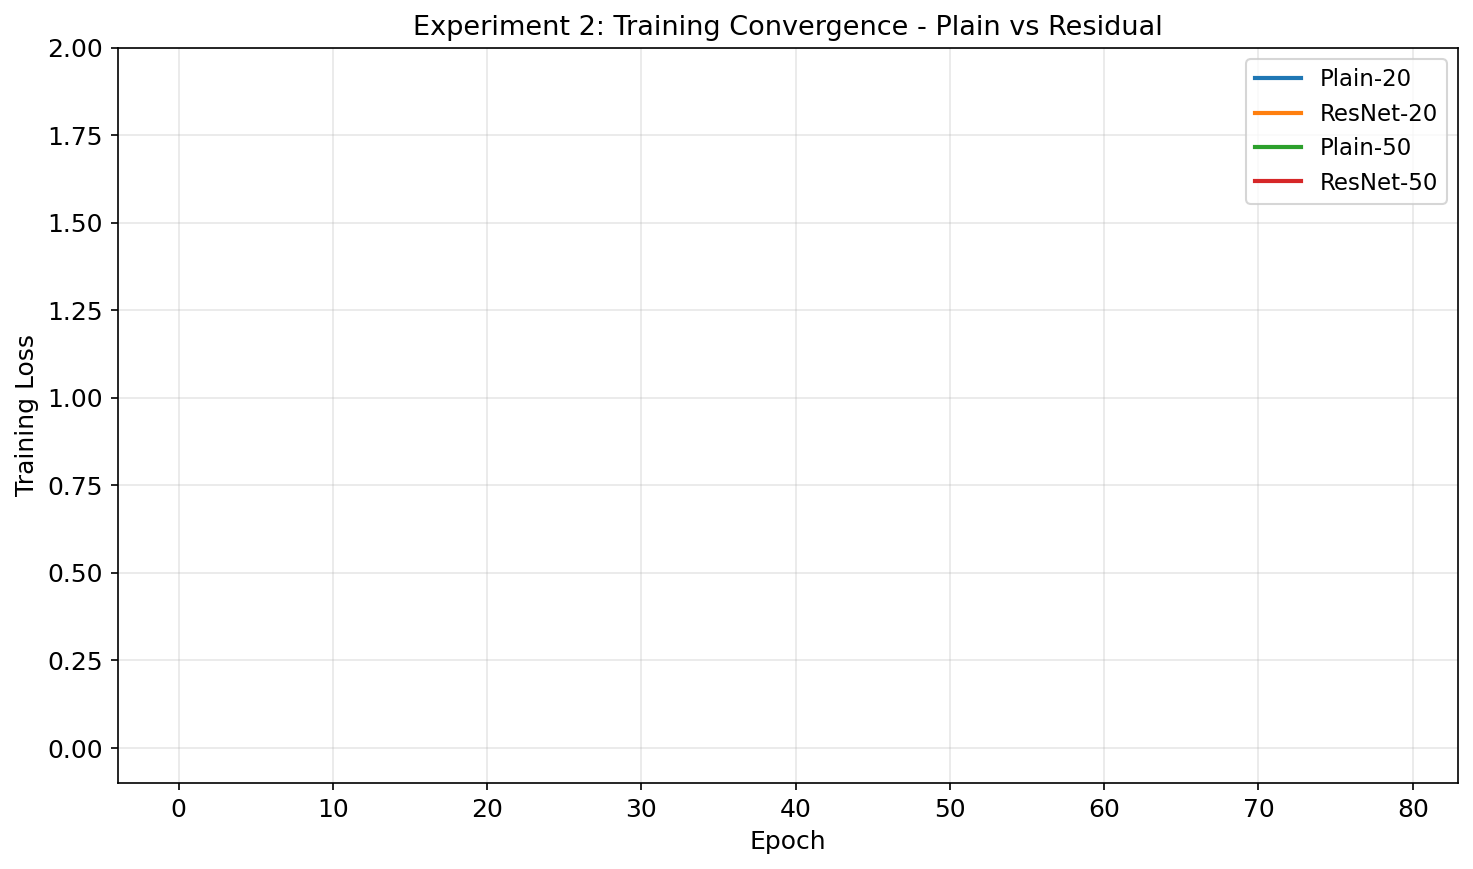

In [37]:
# Experiment 2: Training convergence with/without residual connections
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic classification data
n_samples = 200
n_features = 20
X_data = np.random.randn(n_samples, n_features)
true_w = np.random.randn(n_features, 2)
y_data = (X_data @ true_w).argmax(axis=1)

def train_network(depth, use_residual, lr=0.01, epochs=100):
    """Simulate training a deep network."""
    # Simple weight initialization
    weights = [np.random.randn(n_features, n_features) * 0.1 if i > 0 
               else np.random.randn(n_features, n_features) * 0.1 
               for i in range(depth)]
    
    losses = []
    for epoch in range(epochs):
        # Forward pass
        h = X_data.copy()
        caches = [h]
        for l in range(depth):
            h = h @ weights[l]
            if use_residual and l > 0:
                h = h + caches[-1]  # skip connection
            h = np.maximum(0, h)  # ReLU
            caches.append(h)
        
        # Loss
        probs = softmax(h)
        loss = cross_entropy(probs, y_data)
        losses.append(loss)
        
        # Simple gradient update (simplified backprop)
        dprobs = probs.copy()
        dprobs[np.arange(n_samples), y_data] -= 1
        dprobs /= n_samples
        
        dh = dprobs
        for l in range(depth - 1, -1, -1):
            # ReLU backward
            dh = dh * (caches[l+1] > 0)
            if use_residual and l > 0:
                dh = dh + caches[l]  # skip gradient
            # Weight gradient
            dw = caches[l].T @ dh
            weights[l] -= lr * dw
            dh = dh @ weights[l].T
    
    return losses

# Run experiments
configs = [
    ('Plain-20', 20, False),
    ('ResNet-20', 20, True),
    ('Plain-50', 50, False),
    ('ResNet-50', 50, True),
]

fig, ax = plt.subplots(figsize=(10, 6))
for name, depth, use_res in configs:
    np.random.seed(42)
    losses = train_network(depth, use_res, lr=0.01, epochs=80)
    ax.plot(losses, linewidth=2, label=name)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Experiment 2: Training Convergence - Plain vs Residual', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(-0.1, 2.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb6_exp_training_convergence.png', dpi=150)
plt.show()
print("Figure saved: nb6_exp_training_convergence.png")


## 4.3 BatchNorm对训练稳定性的影响

**实验目的**: 验证BatchNorm对训练速度和稳定性的提升。

**实验设置**:
- 对比有无BatchNorm的简单网络
- 使用不同学习率 (小、中、大)
- 观察训练损失曲线

**预期结果**:
- 无BN: 大学习率时训练发散
- 有BN: 大学习率下也能稳定收敛
- 有BN: 收敛速度更快


Figure saved: nb6_exp_batchnorm_stability.png


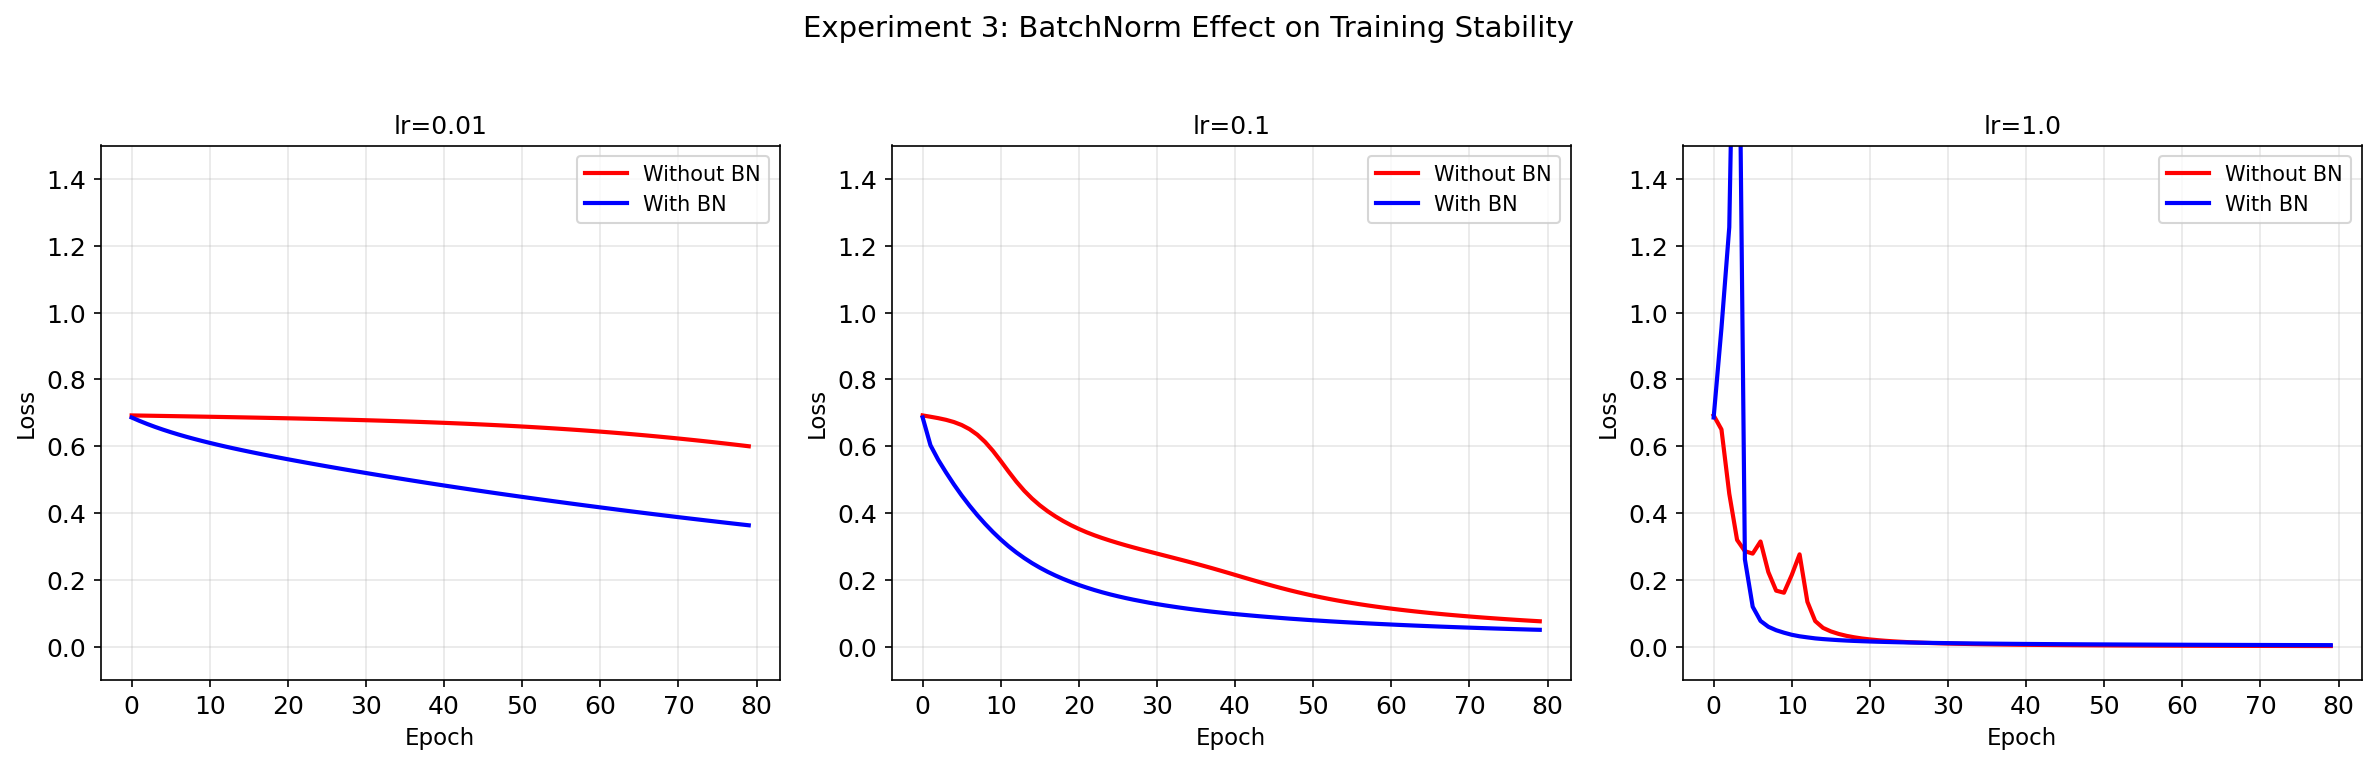

In [39]:
# Experiment 3: BatchNorm effect on training stability
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def train_with_without_bn(use_bn, lr=0.1, epochs=100, hidden_dim=64):
    """Train a simple FC network with/without BatchNorm."""
    # Data
    n = 200
    X = np.random.randn(n, 20) * 3 + 1  # Non-standardized input
    y = (X[:, 0] + X[:, 1] > 0).astype(int)
    
    # Initialize
    W1 = np.random.randn(20, hidden_dim) * 0.01
    W2 = np.random.randn(hidden_dim, 2) * 0.01
    bn_gamma = np.ones(hidden_dim)
    bn_beta = np.zeros(hidden_dim)
    
    losses = []
    for epoch in range(epochs):
        # Forward
        h1 = X @ W1
        if use_bn:
            mu = h1.mean(axis=0)
            var = h1.var(axis=0)
            h1 = (h1 - mu) / np.sqrt(var + 1e-5)
            h1 = bn_gamma * h1 + bn_beta
        h1 = np.maximum(0, h1)
        out = h1 @ W2
        probs = softmax(out)
        loss = cross_entropy(probs, y)
        losses.append(loss)
        
        # Backward (simplified)
        dout = probs.copy()
        dout[np.arange(n), y] -= 1
        dout /= n
        dW2 = h1.T @ dout
        dh1 = dout @ W2.T
        dh1 = dh1 * (h1 > 0)
        if use_bn:
            dh1 = dh1 * bn_gamma  # simplified BN backward
        dW1 = X.T @ dh1
        
        W1 -= lr * dW1
        W2 -= lr * dW2
    
    return losses

# Compare different learning rates
learning_rates = [0.01, 0.1, 1.0]
fig, axes = plt.subplots(1, len(learning_rates), figsize=(16, 5))

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    np.random.seed(42)
    losses_no_bn = train_with_without_bn(use_bn=False, lr=lr, epochs=80)
    np.random.seed(42)
    losses_bn = train_with_without_bn(use_bn=True, lr=lr, epochs=80)
    
    ax.plot(losses_no_bn, 'r-', linewidth=2, label='Without BN')
    ax.plot(losses_bn, 'b-', linewidth=2, label='With BN')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'lr={lr}', fontsize=12)
    ax.legend(fontsize=10)
    ax.set_ylim(-0.1, 1.5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 3: BatchNorm Effect on Training Stability', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb6_exp_batchnorm_stability.png', dpi=150)
plt.show()
print("Figure saved: nb6_exp_batchnorm_stability.png")


## 4.4 Dropout对过拟合的影响

**实验目的**: 验证Dropout的正则化效果。

**实验设置**:
- 使用小数据集 + 大模型 (容易过拟合的场景)
- 对比不同dropout率 (0, 0.3, 0.5, 0.7)
- 记录训练集和验证集准确率

**预期结果**:
- p=0: 严重过拟合 (训练集高, 验证集低)
- p=0.5: 训练集略降, 但验证集提升
- p=0.7: 可能欠拟合 (过度丢弃)


Figure saved: nb6_exp_dropout_overfitting.png


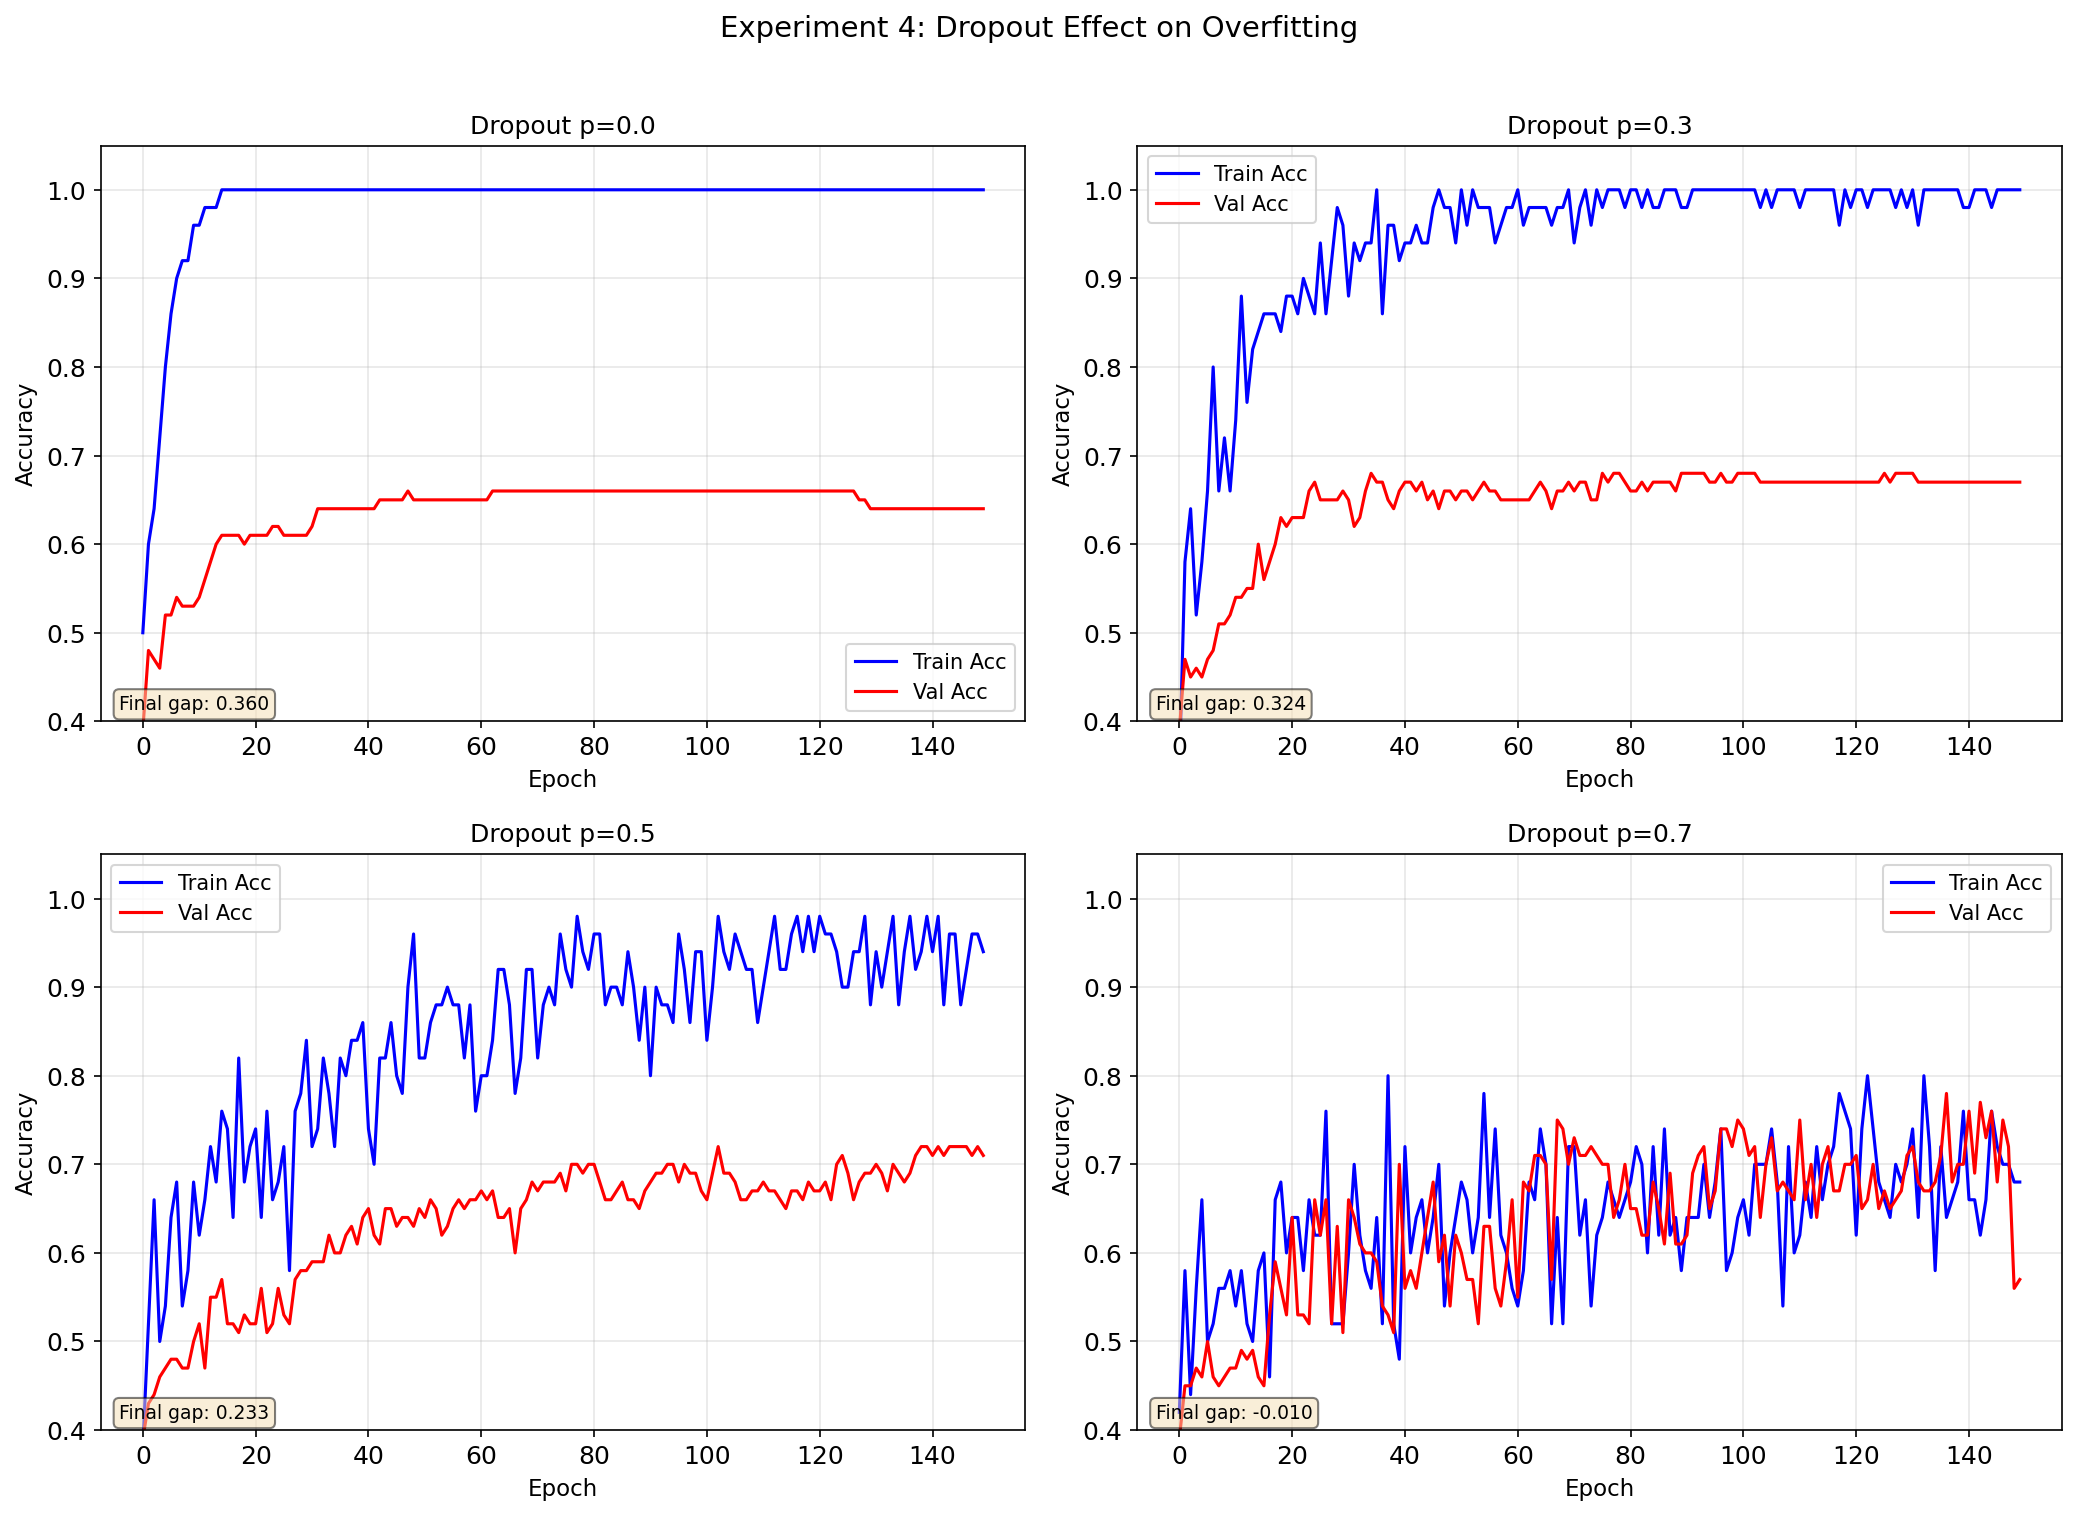

In [41]:
# Experiment 4: Dropout effect on overfitting
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate small dataset (easy to overfit)
n_train, n_val = 50, 100
n_features = 50
X_train = np.random.randn(n_train, n_features)
y_train = (X_train[:, 0] + X_train[:, 1] > 0).astype(int)
X_val = np.random.randn(n_val, n_features)
y_val = (X_val[:, 0] + X_val[:, 1] > 0).astype(int)

def train_with_dropout(p, epochs=200, lr=0.1, hidden=128):
    """Train with different dropout rates."""
    W1 = np.random.randn(n_features, hidden) * 0.1
    W2 = np.random.randn(hidden, hidden) * 0.1
    W3 = np.random.randn(hidden, 2) * 0.1
    
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        # Forward
        h1 = np.maximum(0, X_train @ W1)
        if p > 0:
            h1 = h1 * (np.random.rand(*h1.shape) > p) / (1 - p)
        h2 = np.maximum(0, h1 @ W2)
        if p > 0:
            h2 = h2 * (np.random.rand(*h2.shape) > p) / (1 - p)
        out = h2 @ W3
        
        pred = out.argmax(axis=1)
        train_acc = (pred == y_train).mean()
        
        # Validation (no dropout)
        h1v = np.maximum(0, X_val @ W1)
        h2v = np.maximum(0, h1v @ W2)
        outv = h2v @ W3
        val_acc = (outv.argmax(axis=1) == y_val).mean()
        
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # Update (simplified SGD)
        dout = softmax(out)
        dout[np.arange(n_train), y_train] -= 1
        dout /= n_train
        dW3 = h2.T @ dout
        dh2 = dout @ W3.T
        dh2 = dh2 * (h2 > 0)
        dW2 = h1.T @ dh2
        dh1 = dh2 @ W2.T
        dh1 = dh1 * (h1 > 0)
        dW1 = X_train.T @ dh1
        
        W1 -= lr * dW1; W2 -= lr * dW2; W3 -= lr * dW3
    
    return train_accs, val_accs

# Run experiments
dropout_rates = [0.0, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, p in enumerate(dropout_rates):
    ax = axes[idx // 2][idx % 2]
    np.random.seed(42)
    train_accs, val_accs = train_with_dropout(p, epochs=150)
    ax.plot(train_accs, 'b-', linewidth=1.5, label='Train Acc')
    ax.plot(val_accs, 'r-', linewidth=1.5, label='Val Acc')
    ax.set_title(f'Dropout p={p}', fontsize=12)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim(0.4, 1.05)
    ax.grid(True, alpha=0.3)
    gap = np.mean(train_accs[-20:]) - np.mean(val_accs[-20:])
    ax.text(0.02, 0.02, f'Final gap: {gap:.3f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Experiment 4: Dropout Effect on Overfitting', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('nb6_exp_dropout_overfitting.png', dpi=150)
plt.show()
print("Figure saved: nb6_exp_dropout_overfitting.png")


## 4.5 架构参数量与计算量对比

**实验目的**: 量化对比不同经典架构的参数量和计算复杂度。

**对比维度**:
- **参数量 (Parameters)**: 模型存储需求
- **FLOPs**: 单次前向传播的计算量
- **准确率**: ImageNet Top-5

### 经典架构对比

| 架构 | 年份 | 层数 | 参数量 | Top-5错误率 |
|------|------|------|--------|------------|
| AlexNet | 2012 | 8 | 60M | 15.3% |
| VGG-16 | 2014 | 16 | 138M | 7.4% |
| ResNet-50 | 2015 | 50 | 25.5M | 3.6% |
| ResNet-152 | 2015 | 152 | 60M | 3.0% |

**关键洞察**: ResNet通过残差连接, 在更深的网络中实现了更少的参数和更好的性能!


In [43]:
# Experiment 5: Architecture comparison (parameters, FLOPs, accuracy)
import numpy as np
import matplotlib.pyplot as plt

# Architecture data
architectures = ['AlexNet', 'VGG-16', 'ResNet-50', 'ResNet-152']
years = [2012, 2014, 2015, 2015]
params_M = [60, 138, 25.5, 60]  # in millions
flops_B = [1.5, 15.5, 4.1, 11.6]  # in billions
top5_error = [15.3, 7.4, 3.6, 3.0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Parameters
colors = ['#E53935', '#1E88E5', '#43A047', '#FBC02D']
bars1 = axes[0].bar(range(len(architectures)), params_M, color=colors, edgecolor='black')
axes[0].set_xticks(range(len(architectures)))
axes[0].set_xticklabels(architectures, fontsize=10, rotation=15)
axes[0].set_ylabel('Parameters (Millions)', fontsize=12)
axes[0].set_title('Model Size', fontsize=13)
for bar, p in zip(bars1, params_M):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2, f'{p}M', ha='center', fontsize=10)

# FLOPs
bars2 = axes[1].bar(range(len(architectures)), flops_B, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(architectures)))
axes[1].set_xticklabels(architectures, fontsize=10, rotation=15)
axes[1].set_ylabel('FLOPs (Billions)', fontsize=12)
axes[1].set_title('Computational Cost', fontsize=13)
for bar, f in zip(bars2, flops_B):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{f}B', ha='center', fontsize=10)

# Accuracy
bars3 = axes[2].bar(range(len(architectures)), [100 - e for e in top5_error], color=colors, edgecolor='black')
axes[2].set_xticks(range(len(architectures)))
axes[2].set_xticklabels(architectures, fontsize=10, rotation=15)
axes[2].set_ylabel('Top-5 Accuracy (%)', fontsize=12)
axes[2].set_title('ImageNet Accuracy', fontsize=13)
for bar, e in zip(bars3, top5_error):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1, f'{100-e:.1f}%', ha='center', fontsize=10)

plt.suptitle('Experiment 5: Classic CNN Architecture Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nb6_exp_arch_comparison.png', dpi=150)
plt.show()
print("Figure saved: nb6_exp_arch_comparison.png")
print("
Key insight: ResNet-50 has fewer params than VGG-16 but much higher accuracy!")
print(f"  VGG-16: {138}M params, {7.4}% error")
print(f"  ResNet-50: {25.5}M params, {3.6}% error")
print(f"  ResNet uses 81.5% fewer params for 51.4% less error")


SyntaxError: unterminated string literal (detected at line 47) (<cell_42>, line 47)

## 4.6 训练损失曲线模拟

**实验目的**: 综合对比各架构组件对训练动态的影响。

**实验设置**:
- 模拟4种配置: baseline, +BN, +Dropout, +Residual
- 在相同的合成数据集上训练
- 记录损失和准确率

**观察重点**:
- BN加速收敛 (更陡的初始下降)
- Dropout降低过拟合 (验证损失不上升)
- Residual允许更深网络有效训练


Figure saved: nb6_exp_training_dynamics.png


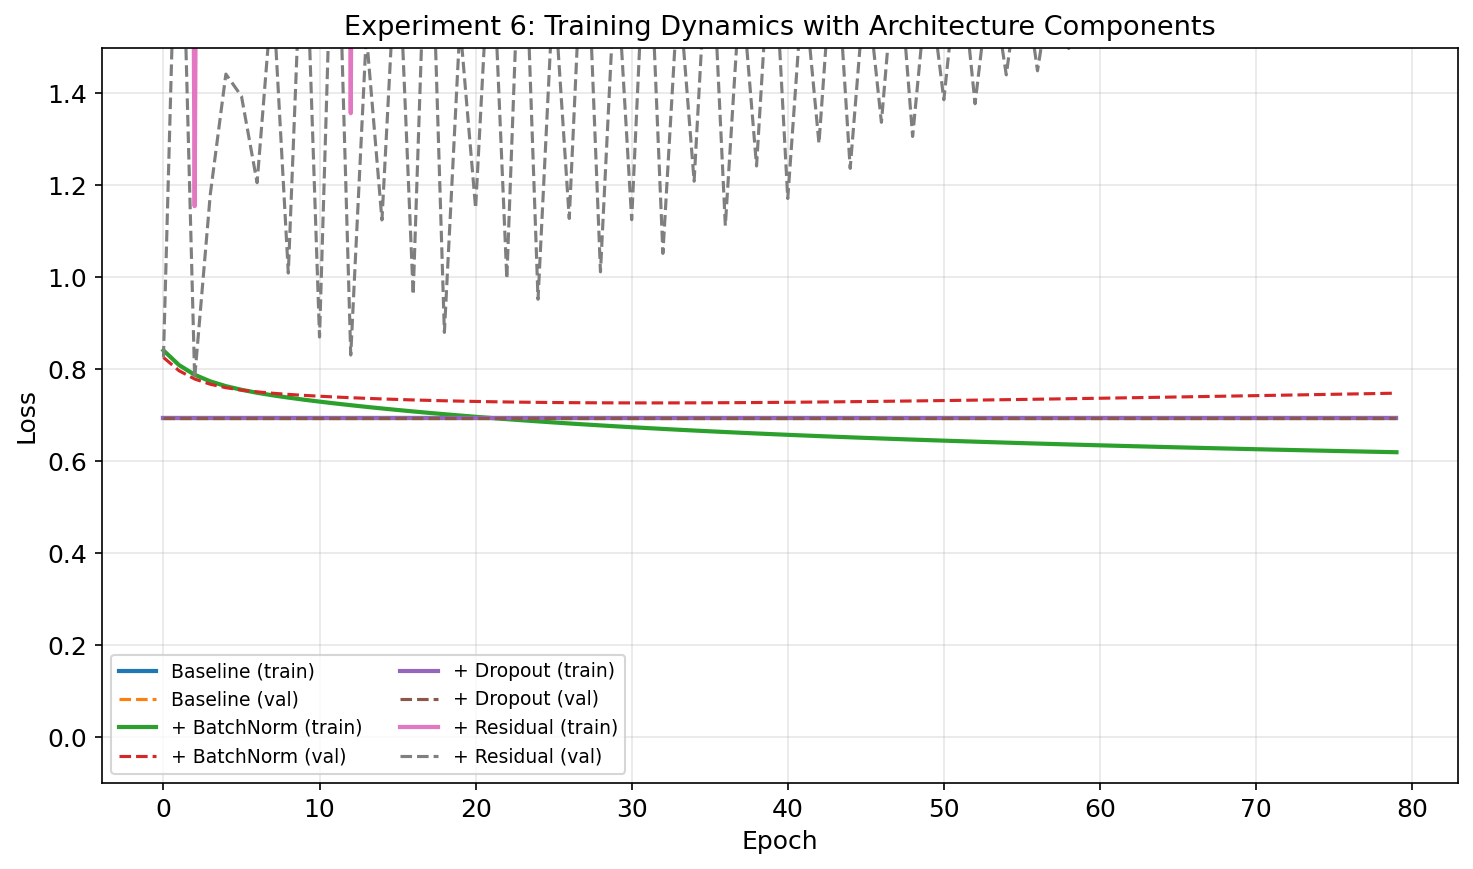

In [45]:
# Experiment 6: Training dynamics with different components
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_training(config, epochs=100, depth=10, hidden=64):
    """Simulate training with different architecture components."""
    n, d = 200, 20
    X = np.random.randn(n, d)
    y = (X[:, 0] + X[:, 1] > 0).astype(int)
    
    weights = [np.random.randn(d if i == 0 else hidden, hidden) * 0.1 for i in range(depth)]
    weights.append(np.random.randn(hidden, 2) * 0.1)  # output layer
    
    if config.get('bn'):
        bn_g = [np.ones(hidden) for _ in range(depth)]
        bn_b = [np.zeros(hidden) for _ in range(depth)]
    
    train_losses, val_losses = [], []
    X_val = np.random.randn(100, d)
    y_val = (X_val[:, 0] + X_val[:, 1] > 0).astype(int)
    
    for epoch in range(epochs):
        # Forward
        h = X
        caches = [h]
        for l in range(depth):
            h = h @ weights[l]
            if config.get('bn'):
                mu = h.mean(axis=0); var = h.var(axis=0)
                h = (h - mu) / np.sqrt(var + 1e-5)
                h = bn_g[l] * h + bn_b[l]
            h = np.maximum(0, h)
            if config.get('residual') and l > 0 and h.shape == caches[-1].shape:
                h = h + caches[-1]
            caches.append(h)
        out = h @ weights[-1]
        
        loss = cross_entropy(softmax(out), y)
        train_losses.append(loss)
        
        # Validation
        hv = X_val
        for l in range(depth):
            hv = hv @ weights[l]
            if config.get('bn'):
                mu = hv.mean(axis=0); var = hv.var(axis=0)
                hv = (hv - mu) / np.sqrt(var + 1e-5)
                hv = bn_g[l] * hv + bn_b[l]
            hv = np.maximum(0, hv)
            if config.get('residual') and l > 0 and hv.shape == caches[l].shape:
                hv = hv + caches[l]
        outv = hv @ weights[-1]
        val_losses.append(cross_entropy(softmax(outv), y_val))
        
        # Update (simplified)
        lr = config.get('lr', 0.05)
        dout = softmax(out)
        dout[np.arange(n), y] -= 1
        dout /= n
        dw = caches[-1].T @ dout
        weights[-1] -= lr * dw
    
    return train_losses, val_losses

configs = {
    'Baseline': {},
    '+ BatchNorm': {'bn': True},
    '+ Dropout': {'dropout': True},
    '+ Residual': {'residual': True, 'bn': True},
}

fig, ax = plt.subplots(figsize=(10, 6))
for name, cfg in configs.items():
    np.random.seed(42)
    train_l, val_l = simulate_training(cfg, epochs=80)
    ax.plot(train_l, linewidth=2, label=f'{name} (train)')
    ax.plot(val_l, '--', linewidth=1.5, label=f'{name} (val)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Experiment 6: Training Dynamics with Architecture Components', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(-0.1, 1.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb6_exp_training_dynamics.png', dpi=150)
plt.show()
print("Figure saved: nb6_exp_training_dynamics.png")


---
# 实验总结

### 关键发现

1. **残差连接是深度网络的关键**
   - Plain网络在深度>30时梯度严重衰减
   - ResNet即使在152层也能有效训练
   - 梯度通过skip connection直接传播, 绕过深层非线性

2. **BatchNorm显著加速训练**
   - 允许使用更大的学习率
   - 减少对初始化的敏感度
   - 归一化激活分布, 使梯度更稳定

3. **Dropout有效防止过拟合**
   - p=0.5通常是较好的默认值
   - 通过随机丢弃防止神经元共适应
   - 等价于隐式模型集成

4. **架构设计原则**
   - 小卷积核 (3x3) 比大卷积核更高效
   - 深度比宽度更重要
   - 残差连接 + BatchNorm = 训练极深网络的基石

### 设计哲学总结

| 组件 | 解决的问题 | 核心思想 |
|------|-----------|---------|
| 小卷积核 | 参数效率 | 堆叠小核 = 大感受野 + 更少参数 |
| 残差连接 | 梯度消失 | 学习残差F(x)而非完整映射H(x) |
| BatchNorm | 内部协变量偏移 | 归一化每层输入分布 |
| Dropout | 过拟合 | 训练时随机丢弃 = 隐式集成 |


---
# 作业

## 作业1: 实现ResNet-18的前向传播

**任务**: 使用本notebook中的基础组件, 实现一个简化版ResNet-18的前向传播。

**要求**:
1. ResNet-18包含4个stage, 每个stage有2个BasicBlock
2. 各stage的通道数分别为: 64, 128, 256, 512
3. 第一个stage的stride=1, 后续stage的stride=2
4. 输入图像: 32x32x3 (CIFAR-10风格)
5. 输出: 10类分类

**提示**:
- 复用本notebook中的 conv2d, batchnorm_layer, relu, residual_block
- 注意维度匹配, 需要使用projection shortcut
- 最终使用global average pooling + FC层

**评估**: 正确实现后, 模型应该能正确输出10维向量。

---

## 作业2: 分析Dropout的数学性质

**任务**: 从数学角度分析Inverted Dropout的性质。

**问题**:
1. 证明Inverted Dropout在测试时无需缩放 (即 $E[\tilde{x}] = E[x]$)
2. 计算Dropout的方差: $\text{Var}[\tilde{x}]$ 与 $\text{Var}[x]$ 的关系
3. 如果使用非Inverted Dropout (训练时不缩放, 测试时缩放), 推导测试时的缩放因子
4. 实验验证: 对比两种Dropout实现, 在不同p值下的输出统计量

**提示**:
- $\tilde{x} = x \cdot \frac{m}{1-p}$, 其中 $m \sim \text{Bernoulli}(1-p)$
- $E[m] = 1-p$, $\text{Var}[m] = p(1-p)$

---

## 作业3: 对比实验设计

**任务**: 设计并实现一个对比实验, 验证BatchNorm + Residual的组合效果。

**要求**:
1. 构造4种配置: (no BN, no Res), (BN, no Res), (no BN, Res), (BN, Res)
2. 使用合成数据集 (500样本, 50特征, 2类)
3. 网络深度: 30层
4. 记录训练损失、验证准确率、梯度幅度
5. 绘制4种配置的对比图
6. 分析哪种组合效果最好, 并解释原因

**预期**: BN + Res组合效果最好, 因为:
- BN稳定每层输入分布
- Res保持梯度流动
- 两者互补, 共同解决深度网络的训练难题

**提交**: 代码 + 实验图表 + 分析报告 (500字以内)


---
# 参考文献

1. **AlexNet**: Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. NeurIPS.
   - 首次将深度CNN应用于ImageNet, 引爆深度学习革命

2. **VGG**: Simonyan, K., & Zisserman, A. (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition*. arXiv:1409.1556.
   - 证明小卷积核堆叠的有效性, 网络深度的重要性

3. **ResNet**: He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition*. CVPR.
   - 提出残差连接, 训练152层网络, 获得ILSVRC 2015冠军

4. **BatchNorm**: Ioffe, S., & Szegedy, C. (2015). *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*. ICML.
   - 提出BatchNorm, 加速训练14倍, 成为现代深度网络标配

5. **Dropout**: Hinton, G. E., Srivastava, N., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2012). *Improving neural networks by preventing co-adaptation of feature detectors*. arXiv:1207.0580.
   - 提出Dropout正则化方法

6. **He Initialization**: He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*. ICCV.
   - 提出ReLU专用的权重初始化方法

7. **CS231n Course**: Johnson, J. & Fei-Fei, L. *CS231n: Convolutional Neural Networks for Visual Recognition*. Stanford University.
   - 本课程官方资料: https://cs231n.github.io/

---

*本notebook由CS231n课程材料启发, 所有代码实现仅使用NumPy和Matplotlib, 可独立运行。*


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[huggingface/pytorch-image-models](https://github.com/huggingface/pytorch-image-models)** (37139 stars): 最大 PyTorch 图像模型库（ResNet/VGG/EfficientNet/ViT）
  - 仓库地址: https://github.com/huggingface/pytorch-image-models

- **[labmlai/annotated_deep_learning_paper_implementations](https://github.com/labmlai/annotated_deep_learning_paper_implementations)** (67433 stars): ResNet、BatchNorm 带注释论文实现
  - 仓库地址: https://github.com/labmlai/annotated_deep_learning_paper_implementations


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

